<a href="https://colab.research.google.com/github/andrelmsunb/Intrus-es-em-Sess-es-de-Rede/blob/main/C%C3%B3pia_de_C%C3%B3pia_de_MVP_IDS_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Pipeline de Dados em Nuvem para Detecção de Intrusões em Sessões de Rede

### Do requisito acadêmico ao manuscrito submissível em periódico internacional

**Universidade de Brasília — Programa Profissionalizante em Engenharia Elétrica**
**Prof. André Luiz Marques Serrano**

---

Este notebook implementa, de ponta a ponta, o pipeline exigido no documento *MVP — Apresentação e Requisitos*
(Objetivo → Coleta → Modelagem → Carga → Análise → Autoavaliação) e, sobre esse mesmo pipeline,
acrescenta a camada de rigor metodológico exigida por um periódico internacional indexado:
validação cruzada repetida, intervalos de confiança por *bootstrap*, testes de significância pareados
com correção para múltiplas comparações, análise de calibração, seleção de limiar sensível a custo,
explicabilidade e estudo de ablação.

**Mapeamento explícito com a rubrica de avaliação do MVP (10,0 pt):**

| Critério da rubrica | Pontuação | Seção deste notebook |
|---|---|---|
| Objetivo | 1,0 | §1 |
| Coleta | 0,5 | §3 |
| Modelagem | 2,0 | §4 (esquema + catálogo de dados) |
| Carga | 1,0 | §5 (ETL e persistência) |
| Análise | 3,0 | §6 (qualidade), §7–§10 (solução e discussão) |
| Autoavaliação | 0,5 | §13 |
| Capricho | 2,0 | transversal (§11 artefatos, §12 artigo, §14 reprodutibilidade) |

---

> ### ⚠️ Advertência de integridade científica — leia antes de submeter
>
> A base escolhida (`dnkumars/cybersecurity-intrusion-detection-dataset`) é declarada pelo próprio autor
> no Kaggle como **sintética** (*tags*: `synthetic`, `tabular`, `cyber security`). Isso é perfeitamente
> adequado para o MVP da disciplina, mas **não sustenta, sozinho, uma alegação de desempenho de IDS em
> periódico internacional**: qualquer revisor competente rejeitará a inferência de validade externa.
>
> Há duas saídas honestas, ambas contempladas neste notebook:
>
> 1. **Reposicionar a contribuição.** O artigo não afirma "detectamos intrusões com AUROC *x*"; ele afirma
>    "propomos e demonstramos um *pipeline* reprodutível, auditável e sensível a custo para triagem de
>    sessões, instanciado em dados sintéticos". A contribuição é metodológica e de engenharia de dados.
> 2. **Validação externa obrigatória.** Replicar §7–§10 em pelo menos uma base real e consagrada
>    (CIC-IDS2017, UNSW-NB15, NSL-KDD) e reportar as duas. O notebook foi escrito com o esquema
>    parametrizado justamente para permitir essa troca (§14.3).
>
> Nenhum número deste notebook deve ser transcrito para o manuscrito sem ter sido efetivamente
> executado. Todas as células de texto do artigo usam marcadores `{{...}}` preenchidos programaticamente
> a partir das saídas reais (§11).

---
# 1. Objetivo

> *"Comece pelo objetivo do seu trabalho. Antes de iniciar sua busca pelos dados, pense e descreva
> claramente qual problema deseja resolver com este MVP. Enumere as perguntas que deseja responder."*
> — Requisitos do MVP, §2

## 1.1. Problema

Equipes de operação de segurança (SOC) são submetidas a um volume de sessões de rede muito superior à
sua capacidade de investigação manual. O gargalo raramente é a ausência de sinal — é a **priorização**:
decidir quais sessões merecem inspeção humana quando o custo de um falso negativo (intrusão não detectada)
e o custo de um falso positivo (analista consumido por ruído) são **assimétricos** e, na prática,
raramente explicitados.

O MVP responde à seguinte pergunta de negócio central:

> **É possível construir um pipeline de dados em nuvem que, a partir de metadados de sessão de baixo custo
> de coleta — sem inspeção de payload —, produza um escore de risco calibrado e auditável capaz de
> ordenar sessões para triagem em um SOC?**

A restrição "sem inspeção de *payload*" não é acidental: ela preserva privacidade, sobrevive ao tráfego
cifrado e reduz drasticamente o custo de instrumentação — três condições necessárias para adoção real.

## 1.2. Perguntas a responder

**Perguntas descritivas (respondíveis via SQL no *data warehouse*):**

- **Q1.** Qual é a prevalência de sessões rotuladas como ataque e como ela se distribui por protocolo?
- **Q2.** A reputação do IP de origem (`ip_reputation_score`) discrimina sessões maliciosas? Qual o tamanho do efeito?
- **Q3.** Falhas de autenticação (`failed_logins`, `login_attempts`) apresentam relação monotônica com o rótulo de ataque?
- **Q4.** O tipo de criptografia negociada e o *user agent* declarado (`browser_type`) estão associados ao desfecho?
- **Q5.** O acesso em horário atípico (`unusual_time_access`) agrega informação além dos demais atributos?
- **Q6.** Duração da sessão e tamanho do pacote — atributos volumétricos — carregam sinal, ou são ruído?

**Perguntas preditivas e decisórias (camada de artigo):**

- **Q7.** Qual a capacidade discriminativa alcançável (AUROC, AUPRC, MCC) com modelos tabulares clássicos,
  e a diferença entre eles é **estatisticamente significativa** ou está dentro do ruído amostral?
- **Q8.** Os escores produzidos são **calibrados**? Um escore de 0,8 corresponde de fato a 80% de chance de ataque?
- **Q9.** Qual o limiar de decisão ótimo sob uma razão de custo explícita $c_{FN}/c_{FP}$, e quão sensível
  é a decisão operacional a essa razão?
- **Q10.** Quais atributos sustentam a decisão do modelo, e o pipeline permanece útil sob **ablação** dos
  atributos mais caros de coletar?

## 1.3. Hipóteses

- **H1.** Atributos comportamentais de autenticação e reputação dominam atributos volumétricos na explicação do rótulo.
- **H2.** Modelos não lineares baseados em árvores superam a regressão logística em discriminação, mas a
  diferença é pequena diante do ganho de interpretabilidade do modelo linear.
- **H3.** A escolha do limiar sob custo assimétrico impacta a utilidade operacional mais do que a escolha do algoritmo.

> **Instrução da disciplina:** *"Não é necessário atingir todos os objetivos desenhados nesta seção.
> Assim, não remova perguntas às quais não se conseguiu responder."* — as dez perguntas permanecem
> registradas e são retomadas, uma a uma, na autoavaliação (§13).

## 1.4. Contribuições declaradas (para o *Abstract* do artigo)

1. Um pipeline reprodutível ingestão→*warehouse*→análise, com linhagem verificável por *hash* criptográfico.
2. Um protocolo de avaliação que reporta incerteza (IC *bootstrap*) e significância pareada (McNemar com
   correção de Holm), em vez de tabelas de acurácia pontual — prática ainda dominante na literatura de IDS.
3. Uma formulação de decisão sensível a custo que traduz o escore em política operacional de triagem.
4. Um estudo de ablação que quantifica o custo de instrumentação de cada família de atributos.

---
# 2. Ambiente de execução

Todas as dependências abaixo já vêm instaladas no Google Colab, com exceção de `kagglehub` e `shap`,
tratados com instalação condicional. Nada aqui exige GPU.

In [ ]:
#@title Instalação condicional de dependências { display-mode: "form" }
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        return True
    except ImportError:
        print(f"instalando {pkg} ...")
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
        return r.returncode == 0

HAS_KAGGLEHUB = ensure("kagglehub")
HAS_SHAP      = ensure("shap")
HAS_XGB       = ensure("xgboost")

print("kagglehub:", HAS_KAGGLEHUB, "| shap:", HAS_SHAP, "| xgboost:", HAS_XGB)

kagglehub: True | shap: True | xgboost: True


In [ ]:
#@title Imports, semente global e configuração de figuras
import os, json, hashlib, sqlite3, warnings, platform, datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

# Diretórios de trabalho: tudo que o artigo consome sai daqui.
ROOT    = Path("/content/mvp_ids") if Path("/content").exists() else Path("./mvp_ids")
RAW     = ROOT / "01_raw"
STAGE   = ROOT / "02_staging"
WH      = ROOT / "03_warehouse"
FIG     = ROOT / "04_figures"
TAB     = ROOT / "05_tables"
META    = ROOT / "06_metadata"
for d in (RAW, STAGE, WH, FIG, TAB, META):
    d.mkdir(parents=True, exist_ok=True)

DB_PATH = WH / "ids_warehouse.db"

# Padrão gráfico compatível com submissão (vetorial, fonte serifada, sem grade pesada).
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "legend.frameon": False, "figure.autolayout": False,
})

def save_fig(fig, name):
    # Salva em PNG (rascunho) e PDF vetorial (submissão).
    for ext in ("png", "pdf"):
        fig.savefig(FIG / f"{name}.{ext}")
    print(f"figura salva: {FIG/name}.pdf")

def holm(pvals):
    # Correção de Holm-Bonferroni (step-down), uniformemente mais poderosa que Bonferroni
    # e válida sob qualquer estrutura de dependência. Retorna os p-valores ajustados.
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    adj, running = np.empty(m), 0.0
    for rank, idx in enumerate(np.argsort(p)):
        running = max(running, (m - rank) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj

def mcnemar_test(n01, n10, exact_threshold=25):
    # Teste de McNemar pareado sobre as discordâncias n01 e n10.
    # n pequeno -> binomial exato; caso contrário, qui-quadrado com correção de Edwards.
    n = n01 + n10
    if n == 0:
        return 0.0, 1.0
    if n < exact_threshold:
        return float(min(n01, n10)), float(min(1.0, 2 * stats.binom.cdf(min(n01, n10), n, 0.5)))
    st = (abs(n01 - n10) - 1) ** 2 / n
    return float(st), float(stats.chi2.sf(st, 1))

print("raiz do projeto:", ROOT)
print("execução:", dt.datetime.now().isoformat(timespec="seconds"))

raiz do projeto: /content/mvp_ids
execução: 2026-09-14T18:43:55


---
# 3. Busca e coleta dos dados

## 3.1. Justificativa da escolha da base

| Item | Descrição |
|---|---|
| **Base** | Cybersecurity Intrusion Detection Dataset |
| **Fonte** | Kaggle — `dnkumars/cybersecurity-intrusion-detection-dataset` |
| **URL** | https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset |
| **Natureza** | **Sintética** (declarada pelo autor) |
| **Granularidade** | Uma linha por sessão de rede (`session_id`) |
| **Rótulo** | `attack_detected` ∈ {0, 1} — binário, supervisionado |
| **Licença** | Verificar a aba *License* na página do Kaggle no momento do download e **registrar no repositório** (exigência explícita do §3.1 dos requisitos do MVP) |

**Por que esta base e não CIC-IDS2017 diretamente?** Porque o objetivo declarado em §1.1 é triagem a
partir de *metadados de sessão de baixo custo*, e esta base oferece exatamente esse recorte — 10 atributos
de sessão, sem *payload* e sem as 80+ colunas derivadas do CICFlowMeter, que exigiriam instrumentação de
captura completa. A contrapartida é a natureza sintética, endereçada em §14.3.

## 3.2. Coleta com registro de linhagem

O §3.3 dos requisitos exige que o modelo **descreva a linhagem dos dados**. Não basta dizer "baixei do
Kaggle": registramos origem, carimbo de tempo, tamanho em bytes e **SHA-256** do arquivo bruto. Esse
*hash* é o que permite a um terceiro — ou a um revisor — verificar que analisou o mesmo artefato.

In [ ]:
#@title Download via kagglehub (com fallback para upload manual)
CSV_NAME = "cybersecurity_intrusion_data.csv"
local_csv = RAW / CSV_NAME
source_desc = None

if not local_csv.exists() and HAS_KAGGLEHUB:
    try:
        import kagglehub
        path = kagglehub.dataset_download("dnkumars/cybersecurity-intrusion-detection-dataset")
        for p in Path(path).rglob("*.csv"):
            local_csv.write_bytes(p.read_bytes())
            CSV_NAME = p.name
            source_desc = f"kagglehub://dnkumars/cybersecurity-intrusion-detection-dataset/{p.name}"
            break
        print("download concluído:", local_csv)
    except Exception as e:
        print("kagglehub falhou:", type(e).__name__, e)
        print("Autentique-se: https://www.kaggle.com/settings -> Create New Token -> kaggle.json")

if not local_csv.exists():
    print("\nFALLBACK — faça o upload manual do CSV baixado do Kaggle:")
    try:
        from google.colab import files
        up = files.upload()
        name = next(iter(up))
        local_csv.write_bytes(up[name])
        source_desc = f"upload_manual://{name}"
    except Exception as e:
        raise FileNotFoundError(
            "Coloque o arquivo em " + str(local_csv) + " antes de prosseguir."
        ) from e

assert local_csv.exists(), "CSV bruto ausente."
print("arquivo bruto:", local_csv, f"({local_csv.stat().st_size/1e6:.2f} MB)")

arquivo bruto: /content/mvp_ids/01_raw/cybersecurity_intrusion_data.csv (0.73 MB)


In [ ]:
#@title Manifesto de linhagem (proveniência verificável)
def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

LINEAGE = {
    "dataset_name": "Cybersecurity Intrusion Detection Dataset",
    "publisher": "Kaggle user dnkumars",
    "url": "https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset",
    "nature": "synthetic (declared by publisher)",
    "license": "PREENCHER: copiar da aba License da página do Kaggle",
    "acquisition_method": source_desc or "arquivo pré-existente em 01_raw",
    "acquired_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "file_name": local_csv.name,
    "file_size_bytes": local_csv.stat().st_size,
    "sha256": sha256_of(local_csv),
    "collected_by": "André Luiz Marques Serrano — UnB/PPEE",
    "transformations_applied": [],   # preenchido incrementalmente pelo ETL (§5)
}

(META / "lineage.json").write_text(json.dumps(LINEAGE, indent=2, ensure_ascii=False))
print(json.dumps(LINEAGE, indent=2, ensure_ascii=False))

{
  "dataset_name": "Cybersecurity Intrusion Detection Dataset",
  "publisher": "Kaggle user dnkumars",
  "url": "https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset",
  "nature": "synthetic (declared by publisher)",
  "license": "PREENCHER: copiar da aba License da página do Kaggle",
  "acquisition_method": "arquivo pré-existente em 01_raw",
  "acquired_at_utc": "2026-09-14T18:43:55Z",
  "file_name": "cybersecurity_intrusion_data.csv",
  "file_size_bytes": 725128,
  "sha256": "ef92832692c7ad45225d38f637a6a5c2d26d39a10157654b6c56c61a7850d0f7",
  "collected_by": "André Luiz Marques Serrano — UnB/PPEE",
  "transformations_applied": []
}


/tmp/ipykernel_947/4260800397.py:16: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "acquired_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",


In [ ]:
#@title Leitura bruta e inspeção inicial
df_raw = pd.read_csv(local_csv)
print(f"dimensões: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas\n")
print(df_raw.dtypes.to_string())
df_raw.head()

dimensões: 9,537 linhas x 11 colunas

session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


**Persistência na nuvem.** O §3.2 dos requisitos pede que os dados coletados sejam armazenados na
nuvem. Duas rotas válidas, à escolha:

- **Google Drive** (célula abaixo) — suficiente para o MVP e trivial de evidenciar por *screenshot*.
- **Databricks / S3 / GCS** — rota preferida se o aluno seguir a plataforma de apoio da disciplina;
  neste caso, substitua `DB_PATH` por uma tabela Delta e o `sqlite3` por `spark.sql` (§14.4).

In [ ]:
#@title (Opcional) Persistir a camada bruta no Google Drive
MOUNT_DRIVE = False  #@param {type:"boolean"}

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    dest = Path("/content/drive/MyDrive/MVP_IDS/01_raw")
    dest.mkdir(parents=True, exist_ok=True)
    (dest / local_csv.name).write_bytes(local_csv.read_bytes())
    print("cópia bruta persistida em:", dest)
else:
    print("Drive não montado. Marque MOUNT_DRIVE para evidenciar a persistência em nuvem.")

Drive não montado. Marque MOUNT_DRIVE para evidenciar a persistência em nuvem.


---
# 4. Modelagem dimensional

> *"Você deve construir um modelo de dados em Esquema Estrela ou Snowflake... Independentemente do modelo,
> deve ser construído um Catálogo de Dados contendo minimamente uma descrição detalhada dos dados e de seus
> domínios, com valores mínimos e máximos esperados para dados numéricos e as possíveis categorias para
> dados categóricos."* — Requisitos do MVP, §3.3

## 4.1. Decisão de projeto

A base bruta é um arquivo *flat*: uma linha por sessão, com atributos descritivos textuais repetidos
(`protocol_type`, `encryption_used`, `browser_type`). Adotamos **Esquema Estrela** com uma tabela fato de
grão *sessão* e três dimensões conformadas, mais uma dimensão de contexto temporal derivada.

Justificativa: (i) as três colunas categóricas têm cardinalidade baixa e semântica de dimensão —
são atributos *de contexto*, não medidas; (ii) o esquema estrela torna as consultas de §7 legíveis e
diretamente traduzíveis para o artigo; (iii) permite evoluir para *snowflake* (ex.: `dim_navegador` →
família do motor de renderização) sem refazer a carga.

```
                         ┌──────────────────┐
                         │  dim_protocolo   │
                         │  sk_protocolo PK │
                         │  protocolo       │
                         │  orientado_conexao│
                         └────────┬─────────┘
                                  │
┌──────────────────┐     ┌────────┴──────────────────────┐     ┌──────────────────┐
│ dim_criptografia │     │      fato_sessao              │     │  dim_navegador   │
│ sk_cripto     PK │─────│  sk_sessao              PK    │─────│  sk_navegador PK │
│ algoritmo        │     │  session_id  (chave natural)  │     │  navegador       │
│ forca_relativa   │     │  sk_protocolo           FK    │     │  categoria_agente│
│ eh_moderno       │     │  sk_cripto              FK    │     └──────────────────┘
└──────────────────┘     │  sk_navegador           FK    │
                         │  sk_contexto_temporal   FK    │     ┌──────────────────────┐
                         │  ── medidas ──                │─────│ dim_contexto_temporal│
                         │  network_packet_size          │     │ sk_contexto_temporal │
                         │  session_duration             │     │ horario_atipico      │
                         │  login_attempts               │     │ descricao            │
                         │  failed_logins                │     └──────────────────────┘
                         │  ip_reputation_score          │
                         │  taxa_falha_login  (derivada) │
                         │  ── rótulo ──                 │
                         │  attack_detected              │
                         └───────────────────────────────┘
```

## 4.2. Medidas derivadas (e sua justificativa)

Duas medidas são criadas no ETL, não no modelo original. **Declará-las aqui é um requisito de honestidade
metodológica**: são decisões do analista, não propriedades do dado.

| Medida derivada | Fórmula | Racional |
|---|---|---|
| `taxa_falha_login` | `failed_logins / max(login_attempts, 1)` | Normaliza a falha pelo volume de tentativas. Cinco falhas em cinco tentativas e cinco falhas em cem tentativas são fenômenos distintos. |
| `log_session_duration` | `ln(1 + session_duration)` | Duração de sessão é fortemente assimétrica à direita; a transformação estabiliza a escala para os modelos lineares sem afetar os baseados em árvore. |

⚠️ Ambas são funções apenas de atributos disponíveis **no momento da decisão** — não há vazamento temporal
(*look-ahead bias*). Essa verificação é explícita em §6.4.

In [ ]:
#@title Dicionário semântico: domínios esperados declarados *a priori*
# Declarados ANTES de olhar os dados. O confronto entre o esperado e o observado
# é o que torna a análise de qualidade (§6) uma verificação, e não uma descrição.

SEMANTIC_SPEC = {
    "session_id":          dict(tipo="identificador", dominio="string SID_#####", nulos_permitidos=False,
                                descricao="Chave natural da sessão de rede. Único por linha."),
    "network_packet_size": dict(tipo="numerico_continuo", minimo=0, maximo=2000, unidade="bytes",
                                nulos_permitidos=False,
                                descricao="Tamanho médio do pacote na sessão. Limite superior ancorado no MTU Ethernet típico (1500 B) com folga para jumbo frames."),
    "protocol_type":       dict(tipo="categorico", categorias=["TCP", "UDP", "ICMP"], nulos_permitidos=False,
                                descricao="Protocolo de transporte/rede da sessão."),
    "login_attempts":      dict(tipo="numerico_discreto", minimo=0, maximo=20, unidade="contagem",
                                nulos_permitidos=False,
                                descricao="Número de tentativas de autenticação na sessão."),
    "session_duration":    dict(tipo="numerico_continuo", minimo=0, maximo=20000, unidade="segundos",
                                nulos_permitidos=False,
                                descricao="Duração total da sessão."),
    "encryption_used":     dict(tipo="categorico", categorias=["AES", "DES", None], nulos_permitidos=True,
                                descricao="Algoritmo de criptografia negociado. Ausência é informativa: indica sessão sem criptografia negociada, NÃO um dado faltante por erro de coleta."),
    "ip_reputation_score": dict(tipo="numerico_continuo", minimo=0.0, maximo=1.0, unidade="score",
                                nulos_permitidos=False,
                                descricao="Escore de reputação do IP de origem. Valores maiores indicam pior reputação."),
    "failed_logins":       dict(tipo="numerico_discreto", minimo=0, maximo=20, unidade="contagem",
                                nulos_permitidos=False,
                                descricao="Tentativas de autenticação malsucedidas. Deve ser <= login_attempts."),
    "browser_type":        dict(tipo="categorico",
                                categorias=["Chrome", "Firefox", "Edge", "Safari", "Unknown"],
                                nulos_permitidos=False,
                                descricao="User agent declarado. 'Unknown' é categoria legítima, possivelmente indicativa de cliente não convencional."),
    "unusual_time_access": dict(tipo="binario", categorias=[0, 1], nulos_permitidos=False,
                                descricao="Indicador de acesso fora da janela horária habitual."),
    "attack_detected":     dict(tipo="binario_rotulo", categorias=[0, 1], nulos_permitidos=False,
                                descricao="RÓTULO. 1 = sessão classificada como ataque."),
}

print(f"{len(SEMANTIC_SPEC)} atributos especificados a priori.")
pd.DataFrame(SEMANTIC_SPEC).T[["tipo", "descricao"]]

11 atributos especificados a priori.


,tipo,descricao
session_id,identificador,Chave natural da sessão de rede. Único por linha.
network_packet_size,numerico_continuo,Tamanho médio do pacote na sessão. Limite supe...
protocol_type,categorico,Protocolo de transporte/rede da sessão.
login_attempts,numerico_discreto,Número de tentativas de autenticação na sessão.
session_duration,numerico_continuo,Duração total da sessão.
encryption_used,categorico,Algoritmo de criptografia negociado. Ausência ...
ip_reputation_score,numerico_continuo,Escore de reputação do IP de origem. Valores m...
failed_logins,numerico_discreto,Tentativas de autenticação malsucedidas. Deve ...
browser_type,categorico,User agent declarado. 'Unknown' é categoria le...
unusual_time_access,binario,Indicador de acesso fora da janela horária hab...


In [ ]:
#@title Geração automática do Catálogo de Dados (perfil observado x especificação)
def build_data_catalog(df, spec):
    rows = []
    for col in df.columns:
        s = df[col]
        sp = spec.get(col, {})
        r = {
            "atributo": col,
            "tipo_declarado": sp.get("tipo", "NAO_ESPECIFICADO"),
            "tipo_fisico": str(s.dtype),
            "descricao": sp.get("descricao", ""),
            "n_registros": len(s),
            "n_nulos": int(s.isna().sum()),
            "pct_nulos": round(100 * s.isna().mean(), 3),
            "n_distintos": int(s.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(s) and sp.get("tipo") != "binario":
            q = s.quantile([0.01, 0.25, 0.5, 0.75, 0.99])
            r.update({
                "min_observado": round(float(s.min()), 4),
                "max_observado": round(float(s.max()), 4),
                "media": round(float(s.mean()), 4),
                "desvio_padrao": round(float(s.std()), 4),
                "p01": round(float(q.loc[0.01]), 4), "p25": round(float(q.loc[0.25]), 4),
                "mediana": round(float(q.loc[0.50]), 4),
                "p75": round(float(q.loc[0.75]), 4), "p99": round(float(q.loc[0.99]), 4),
                "min_esperado": sp.get("minimo"), "max_esperado": sp.get("maximo"),
                "unidade": sp.get("unidade", ""),
                "categorias_observadas": "",
            })
        else:
            vc = s.value_counts(dropna=False)
            cats = "; ".join(f"{k}({v})" for k, v in vc.head(12).items())
            r.update({
                "min_observado": None, "max_observado": None, "media": None, "desvio_padrao": None,
                "p01": None, "p25": None, "mediana": None, "p75": None, "p99": None,
                "min_esperado": None, "max_esperado": None, "unidade": "",
                "categorias_observadas": cats if s.nunique() <= 50 else f"{s.nunique()} valores distintos",
            })
        rows.append(r)
    return pd.DataFrame(rows)

catalog = build_data_catalog(df_raw, SEMANTIC_SPEC)
catalog.to_csv(META / "catalogo_de_dados.csv", index=False)
catalog.to_markdown(META / "catalogo_de_dados.md", index=False)
print("Catálogo de Dados gravado em", META)
catalog

Catálogo de Dados gravado em /content/mvp_ids/06_metadata


,atributo,tipo_declarado,tipo_fisico,descricao,n_registros,n_nulos,pct_nulos,n_distintos,min_observado,max_observado,...,desvio_padrao,p01,p25,mediana,p75,p99,min_esperado,max_esperado,unidade,categorias_observadas
0,session_id,identificador,object,Chave natural da sessão de rede. Único por linha.,9537,0,0.000,9537,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,9537 valores distintos
1,network_packet_size,numerico_continuo,int64,Tamanho médio do pacote na sessão. Limite supe...,9537,0,0.000,959,64.0000,1285.0000,...,198.3794,64.0000,365.0000,499.0000,635.0000,968.6400,0.0,2000.0,bytes,
2,protocol_type,categorico,object,Protocolo de transporte/rede da sessão.,9537,0,0.000,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,TCP(6624); UDP(2406); ICMP(507)
3,login_attempts,numerico_discreto,int64,Número de tentativas de autenticação na sessão.,9537,0,0.000,13,1.0000,13.0000,...,1.9630,1.0000,3.0000,4.0000,5.0000,9.0000,0.0,20.0,contagem,
4,session_duration,numerico_continuo,float64,Duração total da sessão.,9537,0,0.000,9532,0.5000,7190.3922,...,786.5601,8.8043,231.9530,556.2775,1105.3806,3659.7524,0.0,20000.0,segundos,
5,encryption_used,categorico,object,Algoritmo de criptografia negociado. Ausência ...,9537,1966,20.614,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,AES(4706); DES(2865); nan(1966)
6,ip_reputation_score,numerico_continuo,float64,Escore de reputação do IP de origem. Valores m...,9537,0,0.000,9537,0.0025,0.9243,...,0.1772,0.0339,0.1919,0.3148,0.4534,0.7709,0.0,1.0,score,
7,failed_logins,numerico_discreto,int64,Tentativas de autenticação malsucedidas. Deve ...,9537,0,0.000,6,0.0000,5.0000,...,1.0340,0.0000,1.0000,1.0000,2.0000,4.0000,0.0,20.0,contagem,
8,browser_type,categorico,object,User agent declarado. 'Unknown' é categoria le...,9537,0,0.000,5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,Chrome(5137); Firefox(1944); Edge(1469); Unkno...
9,unusual_time_access,binario,int64,Indicador de acesso fora da janela horária hab...,9537,0,0.000,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,0(8107); 1(1430)


In [ ]:
#@title DDL do Esquema Estrela (documentação executável do modelo)
DDL = '''
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS fato_sessao;
DROP TABLE IF EXISTS dim_protocolo;
DROP TABLE IF EXISTS dim_criptografia;
DROP TABLE IF EXISTS dim_navegador;
DROP TABLE IF EXISTS dim_contexto_temporal;

CREATE TABLE dim_protocolo (
    sk_protocolo        INTEGER PRIMARY KEY,
    protocolo           TEXT    NOT NULL UNIQUE,
    orientado_conexao   INTEGER NOT NULL           -- 1 = TCP; 0 = UDP/ICMP
);

CREATE TABLE dim_criptografia (
    sk_cripto           INTEGER PRIMARY KEY,
    algoritmo           TEXT    NOT NULL UNIQUE,   -- inclui 'NENHUMA' para ausência negociada
    forca_relativa      INTEGER NOT NULL,          -- 0 nenhuma, 1 legado (DES), 2 moderno (AES)
    eh_moderno          INTEGER NOT NULL
);

CREATE TABLE dim_navegador (
    sk_navegador        INTEGER PRIMARY KEY,
    navegador           TEXT    NOT NULL UNIQUE,
    categoria_agente    TEXT    NOT NULL           -- 'convencional' | 'nao_identificado'
);

CREATE TABLE dim_contexto_temporal (
    sk_contexto_temporal INTEGER PRIMARY KEY,
    horario_atipico      INTEGER NOT NULL UNIQUE,
    descricao            TEXT    NOT NULL
);

CREATE TABLE fato_sessao (
    sk_sessao               INTEGER PRIMARY KEY AUTOINCREMENT,
    session_id              TEXT    NOT NULL UNIQUE,
    sk_protocolo            INTEGER NOT NULL,
    sk_cripto               INTEGER NOT NULL,
    sk_navegador            INTEGER NOT NULL,
    sk_contexto_temporal    INTEGER NOT NULL,
    network_packet_size     REAL    NOT NULL,
    session_duration        REAL    NOT NULL,
    log_session_duration    REAL    NOT NULL,
    login_attempts          INTEGER NOT NULL,
    failed_logins           INTEGER NOT NULL,
    taxa_falha_login        REAL    NOT NULL,
    ip_reputation_score     REAL    NOT NULL,
    attack_detected         INTEGER NOT NULL,
    dt_carga                TEXT    NOT NULL,
    FOREIGN KEY (sk_protocolo)         REFERENCES dim_protocolo(sk_protocolo),
    FOREIGN KEY (sk_cripto)            REFERENCES dim_criptografia(sk_cripto),
    FOREIGN KEY (sk_navegador)         REFERENCES dim_navegador(sk_navegador),
    FOREIGN KEY (sk_contexto_temporal) REFERENCES dim_contexto_temporal(sk_contexto_temporal)
);

CREATE INDEX idx_fato_rotulo    ON fato_sessao(attack_detected);
CREATE INDEX idx_fato_protocolo ON fato_sessao(sk_protocolo);
'''
(WH / "schema.sql").write_text(DDL)
print(DDL)


PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS fato_sessao;
DROP TABLE IF EXISTS dim_protocolo;
DROP TABLE IF EXISTS dim_criptografia;
DROP TABLE IF EXISTS dim_navegador;
DROP TABLE IF EXISTS dim_contexto_temporal;

CREATE TABLE dim_protocolo (
    sk_protocolo        INTEGER PRIMARY KEY,
    protocolo           TEXT    NOT NULL UNIQUE,
    orientado_conexao   INTEGER NOT NULL           -- 1 = TCP; 0 = UDP/ICMP
);

CREATE TABLE dim_criptografia (
    sk_cripto           INTEGER PRIMARY KEY,
    algoritmo           TEXT    NOT NULL UNIQUE,   -- inclui 'NENHUMA' para ausência negociada
    forca_relativa      INTEGER NOT NULL,          -- 0 nenhuma, 1 legado (DES), 2 moderno (AES)
    eh_moderno          INTEGER NOT NULL
);

CREATE TABLE dim_navegador (
    sk_navegador        INTEGER PRIMARY KEY,
    navegador           TEXT    NOT NULL UNIQUE,
    categoria_agente    TEXT    NOT NULL           -- 'convencional' | 'nao_identificado'
);

CREATE TABLE dim_contexto_temporal (
    sk_cont

---
# 5. Carga — pipeline de ETL

> *"Será dado valor à utilização de pipelines de ETL... Deve-se documentar os processos de transformação
> e carga, principalmente os de transformação."* — Requisitos do MVP, §3.4

O ETL é escrito como três funções puras e auditáveis (`extract`, `transform`, `load`), cada uma
registrando o que fez no manifesto de linhagem. **Toda transformação é registrada, inclusive as que
não alteram nenhuma linha** — a ausência de efeito também é evidência.

In [ ]:
#@title E — Extract
def extract(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    LINEAGE["transformations_applied"].append({
        "etapa": "extract", "acao": "leitura do CSV bruto e normalização dos nomes de coluna",
        "linhas": len(df), "colunas": list(df.columns),
    })
    return df

df_ext = extract(local_csv)
print(f"extraído: {df_ext.shape[0]:,} x {df_ext.shape[1]}")

extraído: 9,537 x 11


In [ ]:
#@title T — Transform (cada regra registrada no manifesto)
def transform(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    log = []

    # T1 — deduplicação pela chave natural
    n0 = len(out)
    out = out.drop_duplicates(subset=["session_id"], keep="first")
    log.append({"regra": "T1", "acao": "deduplicação por session_id",
                "linhas_removidas": n0 - len(out)})

    # T2 — ausência informativa em encryption_used -> categoria explícita
    n_missing = int(out["encryption_used"].isna().sum())
    out["encryption_used"] = out["encryption_used"].fillna("NENHUMA")
    log.append({"regra": "T2",
                "acao": "encryption_used ausente tratado como categoria 'NENHUMA' (ausência semântica, não erro de coleta)",
                "valores_imputados": n_missing})

    # T3 — coerção de tipos
    for c in ["login_attempts", "failed_logins", "unusual_time_access", "attack_detected"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").astype("Int64")
    for c in ["network_packet_size", "session_duration", "ip_reputation_score"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    log.append({"regra": "T3", "acao": "coerção explícita de tipos numéricos", "colunas": 7})

    # T4 — regra de integridade de domínio: failed_logins <= login_attempts
    viol = int((out["failed_logins"] > out["login_attempts"]).sum())
    log.append({"regra": "T4", "acao": "verificação failed_logins <= login_attempts",
                "violacoes_detectadas": viol,
                "tratamento": "mantidas e sinalizadas; ver §6.3" if viol else "nenhuma violação"})
    out["flag_incoerencia_login"] = (out["failed_logins"] > out["login_attempts"]).astype(int)

    # T5 — medidas derivadas (declaradas em §4.2)
    out["taxa_falha_login"] = (
        out["failed_logins"].astype(float) / out["login_attempts"].astype(float).clip(lower=1)
    )
    out["log_session_duration"] = np.log1p(out["session_duration"].clip(lower=0))
    log.append({"regra": "T5", "acao": "criação de taxa_falha_login e log_session_duration",
                "novas_colunas": 2})

    # T6 — descarte de linhas sem rótulo (inutilizáveis para a tarefa supervisionada)
    n1 = len(out)
    out = out.dropna(subset=["attack_detected"])
    log.append({"regra": "T6", "acao": "remoção de registros sem rótulo",
                "linhas_removidas": n1 - len(out)})

    out = out.reset_index(drop=True)
    LINEAGE["transformations_applied"].extend(log)
    return out

df_t = transform(df_ext)
pd.DataFrame(LINEAGE["transformations_applied"][1:])

,regra,acao,linhas_removidas,valores_imputados,colunas,violacoes_detectadas,tratamento,novas_colunas
0,T1,deduplicação por session_id,0.0,NaN,NaN,NaN,NaN,NaN
1,T2,encryption_used ausente tratado como categoria...,NaN,1966.0,NaN,NaN,NaN,NaN
2,T3,coerção explícita de tipos numéricos,NaN,NaN,7.0,NaN,NaN,NaN
3,T4,verificação failed_logins <= login_attempts,NaN,NaN,NaN,730.0,mantidas e sinalizadas; ver §6.3,NaN
4,T5,criação de taxa_falha_login e log_session_dura...,NaN,NaN,NaN,NaN,NaN,2.0
5,T6,remoção de registros sem rótulo,0.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#@title L — Load (materialização do esquema estrela no warehouse)
def load(df: pd.DataFrame, db_path: Path) -> dict:
    if db_path.exists():
        db_path.unlink()
    con = sqlite3.connect(db_path)
    con.executescript(DDL)

    ts = dt.datetime.utcnow().isoformat(timespec="seconds") + "Z"

    # --- dimensões ---
    prot = sorted(df["protocol_type"].dropna().unique())
    dim_prot = pd.DataFrame({
        "sk_protocolo": range(1, len(prot) + 1), "protocolo": prot,
        "orientado_conexao": [1 if p.upper() == "TCP" else 0 for p in prot]})

    forca = {"NENHUMA": 0, "DES": 1, "AES": 2}
    cript = sorted(df["encryption_used"].dropna().unique())
    dim_cri = pd.DataFrame({
        "sk_cripto": range(1, len(cript) + 1), "algoritmo": cript,
        "forca_relativa": [forca.get(str(c).upper(), 1) for c in cript],
        "eh_moderno": [1 if str(c).upper() == "AES" else 0 for c in cript]})

    nav = sorted(df["browser_type"].dropna().unique())
    dim_nav = pd.DataFrame({
        "sk_navegador": range(1, len(nav) + 1), "navegador": nav,
        "categoria_agente": ["nao_identificado" if str(n).lower() in ("unknown", "nan")
                             else "convencional" for n in nav]})

    dim_tmp = pd.DataFrame({
        "sk_contexto_temporal": [1, 2], "horario_atipico": [0, 1],
        "descricao": ["acesso em janela horária habitual", "acesso em horário atípico"]})

    for name, d in [("dim_protocolo", dim_prot), ("dim_criptografia", dim_cri),
                    ("dim_navegador", dim_nav), ("dim_contexto_temporal", dim_tmp)]:
        d.to_sql(name, con, if_exists="append", index=False)

    # --- fato: substituição de chaves naturais por surrogate keys ---
    f = df.merge(dim_prot[["sk_protocolo", "protocolo"]],
                 left_on="protocol_type", right_on="protocolo", how="left") \
          .merge(dim_cri[["sk_cripto", "algoritmo"]],
                 left_on="encryption_used", right_on="algoritmo", how="left") \
          .merge(dim_nav[["sk_navegador", "navegador"]],
                 left_on="browser_type", right_on="navegador", how="left") \
          .merge(dim_tmp[["sk_contexto_temporal", "horario_atipico"]],
                 left_on="unusual_time_access", right_on="horario_atipico", how="left")

    fato = f[["session_id", "sk_protocolo", "sk_cripto", "sk_navegador", "sk_contexto_temporal",
              "network_packet_size", "session_duration", "log_session_duration",
              "login_attempts", "failed_logins", "taxa_falha_login",
              "ip_reputation_score", "attack_detected"]].copy()
    fato["dt_carga"] = ts

    orfas = int(fato[["sk_protocolo", "sk_cripto", "sk_navegador",
                      "sk_contexto_temporal"]].isna().any(axis=1).sum())
    assert orfas == 0, f"{orfas} linhas órfãs — falha de integridade referencial."

    fato.to_sql("fato_sessao", con, if_exists="append", index=False)
    con.commit()

    stats = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
             for t in ["fato_sessao", "dim_protocolo", "dim_criptografia",
                       "dim_navegador", "dim_contexto_temporal"]}
    con.close()

    LINEAGE["transformations_applied"].append(
        {"etapa": "load", "acao": "materialização do esquema estrela em SQLite",
         "destino": str(db_path), "linhas_órfãs": orfas, "contagens": stats, "dt_carga": ts})
    return stats

load_stats = load(df_t, DB_PATH)
print("Carga concluída:")
for k, v in load_stats.items():
    print(f"  {k:24s} {v:>8,}")

/tmp/ipykernel_947/3010883294.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = dt.datetime.utcnow().isoformat(timespec="seconds") + "Z"


Carga concluída:
  fato_sessao                 9,537
  dim_protocolo                   3
  dim_criptografia                3
  dim_navegador                   5
  dim_contexto_temporal           2


In [ ]:
#@title Verificação pós-carga: o warehouse contém o que deveria conter?
con = sqlite3.connect(DB_PATH)

checks = {
    "linhas na fato == linhas transformadas":
        con.execute("SELECT COUNT(*) FROM fato_sessao").fetchone()[0] == len(df_t),
    "session_id único na fato":
        con.execute("SELECT COUNT(DISTINCT session_id) FROM fato_sessao").fetchone()[0] == len(df_t),
    "sem FK órfã em dim_protocolo":
        con.execute(
            "SELECT COUNT(*) FROM fato_sessao f "
            "LEFT JOIN dim_protocolo d ON f.sk_protocolo=d.sk_protocolo "
            "WHERE d.sk_protocolo IS NULL").fetchone()[0] == 0,
    "rótulo estritamente binário":
        set(r[0] for r in con.execute(
            "SELECT DISTINCT attack_detected FROM fato_sessao")) <= {0, 1},
    "soma de ataques preservada":
        con.execute("SELECT SUM(attack_detected) FROM fato_sessao").fetchone()[0]
        == int(df_t["attack_detected"].sum()),
}
for k, v in checks.items():
    print(("  OK   " if v else "  FALHA") + f" | {k}")
assert all(checks.values()), "Verificação pós-carga falhou."

(META / "lineage.json").write_text(json.dumps(LINEAGE, indent=2, ensure_ascii=False, default=str))
con.close()
print("\nManifesto de linhagem atualizado com todas as transformações.")

  OK    | linhas na fato == linhas transformadas
  OK    | session_id único na fato
  OK    | sem FK órfã em dim_protocolo
  OK    | rótulo estritamente binário
  OK    | soma de ataques preservada

Manifesto de linhagem atualizado com todas as transformações.


---
# 6. Análise — Parte A: qualidade dos dados

> *"Existem problemas no conjunto de dados? Caso haja, como esses problemas podem ser resolvidos...?
> É possível que não se encontrem problemas... Entretanto, mesmo nestes casos, espera-se que seja feita
> uma análise de valores por atributo e que se demonstre que não foram encontrados problemas."*
> — Requisitos do MVP, §3.5(a)

A análise de qualidade é conduzida como **verificação de conformidade contra a especificação declarada
em §4**, não como descrição livre. Cada atributo é confrontado com seu domínio esperado, e cada desvio
recebe um veredito e um tratamento.

In [ ]:
#@title Relatório de conformidade atributo a atributo
def quality_report(df, spec):
    rows = []
    for col, sp in spec.items():
        if col not in df.columns:
            rows.append({"atributo": col, "verificacao": "presença", "status": "AUSENTE",
                         "detalhe": "coluna não encontrada"}); continue
        s = df[col]

        n_null = int(s.isna().sum())
        rows.append({"atributo": col, "verificacao": "completude",
                     "status": "OK" if (n_null == 0 or sp.get("nulos_permitidos")) else "ATENCAO",
                     "detalhe": f"{n_null} nulos ({100*s.isna().mean():.2f}%)"})

        if sp["tipo"] in ("numerico_continuo", "numerico_discreto"):
            lo, hi = sp.get("minimo"), sp.get("maximo")
            fora = int(((s < lo) | (s > hi)).sum()) if lo is not None else 0
            rows.append({"atributo": col, "verificacao": "domínio numérico",
                         "status": "OK" if fora == 0 else "VIOLACAO",
                         "detalhe": f"observado [{s.min():.3f}, {s.max():.3f}] vs esperado [{lo}, {hi}] — {fora} fora"})
            q1, q3 = s.quantile([0.25, 0.75])
            iqr = q3 - q1
            n_out = int(((s < q1 - 3*iqr) | (s > q3 + 3*iqr)).sum())
            rows.append({"atributo": col, "verificacao": "outliers (Tukey 3·IQR)",
                         "status": "OK" if n_out == 0 else "INSPECIONAR",
                         "detalhe": f"{n_out} pontos ({100*n_out/len(s):.2f}%)"})

        elif sp["tipo"] in ("categorico", "binario", "binario_rotulo"):
            esperadas = {str(c) for c in (sp.get("categorias") or []) if c is not None}
            obs = {str(v) for v in s.dropna().unique()}
            novas = obs - esperadas if esperadas else set()
            rows.append({"atributo": col, "verificacao": "domínio categórico",
                         "status": "OK" if not novas else "INESPERADO",
                         "detalhe": f"observadas={sorted(obs)}" + (f" | não previstas={sorted(novas)}" if novas else "")})

        elif sp["tipo"] == "identificador":
            dup = int(s.duplicated().sum())
            rows.append({"atributo": col, "verificacao": "unicidade",
                         "status": "OK" if dup == 0 else "VIOLACAO",
                         "detalhe": f"{dup} duplicatas"})
    return pd.DataFrame(rows)

qr_raw = quality_report(df_raw, SEMANTIC_SPEC)
qr_raw.to_csv(META / "qualidade_pre_etl.csv", index=False)
print("Distribuição dos vereditos (dados BRUTOS):")
print(qr_raw["status"].value_counts().to_string())
qr_raw

Distribuição dos vereditos (dados BRUTOS):
status
OK             25
INSPECIONAR     2


,atributo,verificacao,status,detalhe
0,session_id,completude,OK,0 nulos (0.00%)
1,session_id,unicidade,OK,0 duplicatas
2,network_packet_size,completude,OK,0 nulos (0.00%)
3,network_packet_size,domínio numérico,OK,"observado [64.000, 1285.000] vs esperado [0, 2..."
4,network_packet_size,outliers (Tukey 3·IQR),OK,0 pontos (0.00%)
5,protocol_type,completude,OK,0 nulos (0.00%)
6,protocol_type,domínio categórico,OK,"observadas=['ICMP', 'TCP', 'UDP']"
7,login_attempts,completude,OK,0 nulos (0.00%)
8,login_attempts,domínio numérico,OK,"observado [1.000, 13.000] vs esperado [0, 20] ..."
9,login_attempts,outliers (Tukey 3·IQR),INSPECIONAR,13 pontos (0.14%)


In [ ]:
#@title Regras de consistência entre atributos (o que uma checagem por coluna não captura)
con = sqlite3.connect(DB_PATH)
fato = pd.read_sql("SELECT * FROM fato_sessao", con)

consistencia = [
    ("failed_logins <= login_attempts",
     int((fato.failed_logins > fato.login_attempts).sum())),
    ("session_duration >= 0",
     int((fato.session_duration < 0).sum())),
    ("ip_reputation_score em [0,1]",
     int(((fato.ip_reputation_score < 0) | (fato.ip_reputation_score > 1)).sum())),
    ("taxa_falha_login em [0,1]",
     int(((fato.taxa_falha_login < 0) | (fato.taxa_falha_login > 1)).sum())),
    ("nenhuma linha integralmente duplicada (exceto SK/carga)",
     int(fato.drop(columns=["sk_sessao", "session_id", "dt_carga"]).duplicated().sum())),
]
cons = pd.DataFrame(consistencia, columns=["regra", "violacoes"])
cons["status"] = np.where(cons.violacoes == 0, "OK", "INVESTIGAR")
cons.to_csv(META / "consistencia_cruzada.csv", index=False)
cons

,regra,violacoes,status
0,failed_logins <= login_attempts,730,INVESTIGAR
1,session_duration >= 0,0,OK
2,"ip_reputation_score em [0,1]",0,OK
3,"taxa_falha_login em [0,1]",730,INVESTIGAR
4,nenhuma linha integralmente duplicada (exceto ...,0,OK


n = 9,537 sessões
prevalência de ataque = 0.4471  (4,264 positivos)
razão negativo:positivo = 1.24:1

Esta razão define a métrica principal do artigo: com desbalanceamento moderado,
AUPRC e MCC informam mais que acurácia — reportar acurácia isolada seria um erro metodológico.
figura salva: /content/mvp_ids/04_figures/fig1_distribuicoes_condicionais.pdf


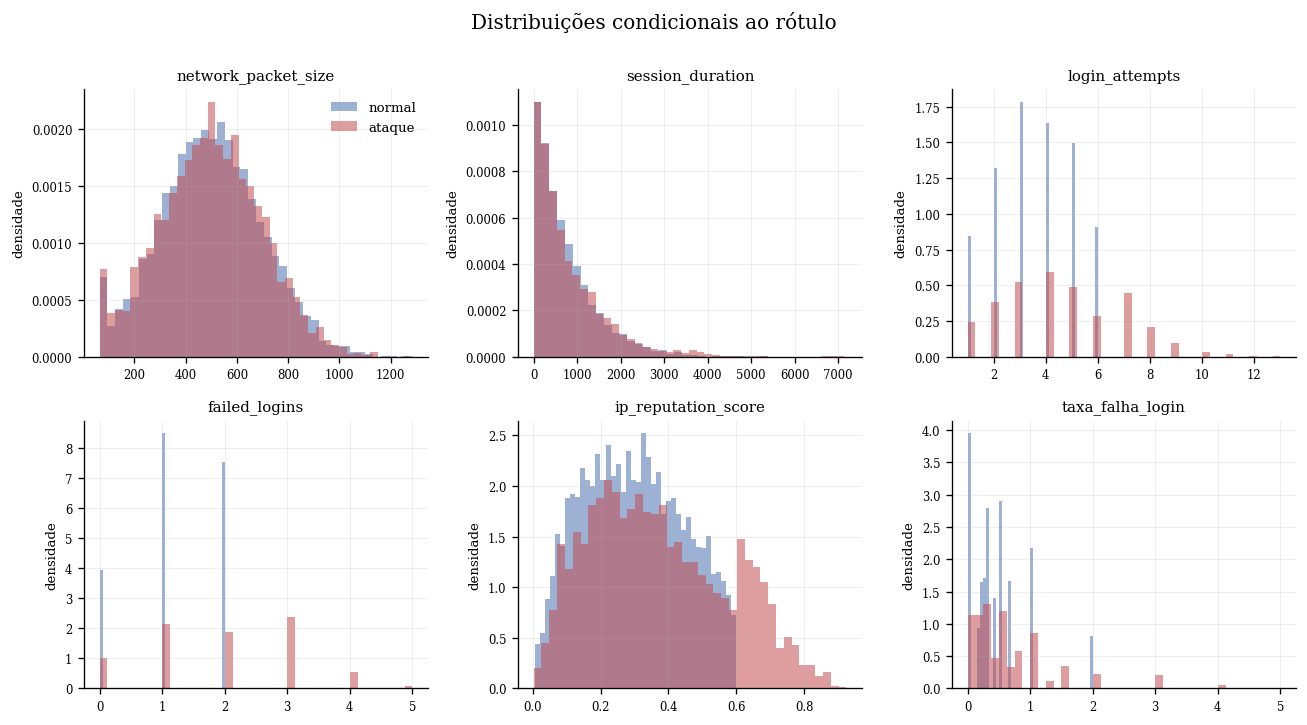

In [ ]:
#@title Perfil univariado e balanceamento do rótulo
prev = fato.attack_detected.mean()
print(f"n = {len(fato):,} sessões")
print(f"prevalência de ataque = {prev:.4f}  ({fato.attack_detected.sum():,} positivos)")
print(f"razão negativo:positivo = {(1-prev)/prev:.2f}:1")
print("\nEsta razão define a métrica principal do artigo: com desbalanceamento moderado,")
print("AUPRC e MCC informam mais que acurácia — reportar acurácia isolada seria um erro metodológico.")

num_cols = ["network_packet_size", "session_duration", "login_attempts",
            "failed_logins", "ip_reputation_score", "taxa_falha_login"]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, c in zip(axes.ravel(), num_cols):
    for lab, cor, nome in [(0, "#4C72B0", "normal"), (1, "#C44E52", "ataque")]:
        ax.hist(fato.loc[fato.attack_detected == lab, c], bins=40, alpha=0.55,
                color=cor, label=nome, density=True)
    ax.set_title(c, fontsize=9); ax.set_ylabel("densidade", fontsize=8)
    ax.tick_params(labelsize=7)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Distribuições condicionais ao rótulo", y=1.00)
fig.tight_layout()
save_fig(fig, "fig1_distribuicoes_condicionais")
plt.show()

### 6.4. Verificação de vazamento de rótulo (*label leakage*)

Um pipeline que atinge desempenho excepcional quase sempre está usando informação que não estaria
disponível no momento da decisão. A verificação abaixo é obrigatória antes de qualquer alegação de
desempenho em publicação: procuramos (i) atributos com correlação quase perfeita com o rótulo e
(ii) capacidade de um único atributo, sozinho, reproduzir o rótulo.

In [ ]:
#@title Diagnóstico de vazamento: nenhum atributo pode "ser" o rótulo
from sklearn.metrics import roc_auc_score

leak = []
for c in num_cols + ["log_session_duration"]:
    auc_single = roc_auc_score(fato.attack_detected, fato[c])
    leak.append({"atributo": c, "AUROC_univariada": round(max(auc_single, 1 - auc_single), 4)})
leak = pd.DataFrame(leak).sort_values("AUROC_univariada", ascending=False)
leak["veredito"] = np.where(leak.AUROC_univariada > 0.98, "SUSPEITA DE VAZAMENTO",
                     np.where(leak.AUROC_univariada > 0.80, "forte preditor (esperado)", "sinal moderado/fraco"))
print("Nenhum atributo deve, isoladamente, atingir AUROC > 0,98.\n")
leak

Nenhum atributo deve, isoladamente, atingir AUROC > 0,98.



,atributo,AUROC_univariada,veredito
3,failed_logins,0.6845,sinal moderado/fraco
2,login_attempts,0.6338,sinal moderado/fraco
4,ip_reputation_score,0.5994,sinal moderado/fraco
5,taxa_falha_login,0.5722,sinal moderado/fraco
1,session_duration,0.5094,sinal moderado/fraco
6,log_session_duration,0.5094,sinal moderado/fraco
0,network_packet_size,0.5020,sinal moderado/fraco


---
# 7. Análise — Parte B.1: respostas via SQL no *data warehouse*

As perguntas descritivas Q1–Q6 são respondidas **em SQL sobre o esquema estrela**, não em pandas.
A escolha é deliberada: demonstra que o modelo dimensional de §4 é funcional e que as respostas são
reproduzíveis por qualquer analista com acesso ao *warehouse*, sem depender deste notebook.

In [ ]:
#@title Q1 — prevalência global e por protocolo
q1 = pd.read_sql('''
    SELECT  d.protocolo,
            COUNT(*)                                       AS n_sessoes,
            SUM(f.attack_detected)                         AS n_ataques,
            ROUND(100.0*AVG(f.attack_detected), 2)         AS pct_ataque,
            ROUND(AVG(f.ip_reputation_score), 4)           AS reputacao_media,
            ROUND(AVG(f.session_duration), 1)              AS duracao_media_s
    FROM fato_sessao f
    JOIN dim_protocolo d ON f.sk_protocolo = d.sk_protocolo
    GROUP BY d.protocolo
    ORDER BY pct_ataque DESC;
''', con)
display(q1)

# Teste de independência entre protocolo e rótulo + tamanho de efeito (V de Cramér)
tab = pd.crosstab(
    pd.read_sql("SELECT d.protocolo FROM fato_sessao f JOIN dim_protocolo d "
                "ON f.sk_protocolo=d.sk_protocolo", con).protocolo,
    fato.attack_detected)
chi2, p, dof, _ = stats.chi2_contingency(tab)
cramer_v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
print(f"\nQui-quadrado: chi2={chi2:.2f}, gl={dof}, p={p:.3e} | V de Cramér={cramer_v:.4f}")
print("Interpretação de V (Cohen): ~0,10 pequeno | ~0,30 médio | ~0,50 grande.")

,protocolo,n_sessoes,n_ataques,pct_ataque,reputacao_media,duracao_media_s
0,UDP,2406,1092,45.39,0.3405,781.9
1,TCP,6624,2963,44.73,0.3287,798.5
2,ICMP,507,209,41.22,0.3221,769.2



Qui-quadrado: chi2=3.83, gl=2, p=1.472e-01 | V de Cramér=0.0200
Interpretação de V (Cohen): ~0,10 pequeno | ~0,30 médio | ~0,50 grande.


In [ ]:
#@title Q2 — reputação de IP: discriminação e tamanho de efeito
q2 = pd.read_sql('''
    SELECT  CASE WHEN attack_detected=1 THEN 'ataque' ELSE 'normal' END AS classe,
            COUNT(*)                                     AS n,
            ROUND(AVG(ip_reputation_score), 4)           AS media,
            ROUND(MIN(ip_reputation_score), 4)           AS minimo,
            ROUND(MAX(ip_reputation_score), 4)           AS maximo
    FROM fato_sessao GROUP BY classe;
''', con)
display(q2)

a = fato.loc[fato.attack_detected == 1, "ip_reputation_score"].values
b = fato.loc[fato.attack_detected == 0, "ip_reputation_score"].values

def cliffs_delta(x, y, n_sample=20000, seed=SEED):
    # Estimativa de delta de Cliff por amostragem (robusta para n grande).
    rng = np.random.default_rng(seed)
    xs = rng.choice(x, min(len(x), n_sample), replace=len(x) < n_sample)
    ys = rng.choice(y, min(len(y), n_sample), replace=len(y) < n_sample)
    gt = np.mean(xs[:, None] > ys[None, :]) if len(xs)*len(ys) < 4e6 else \
         np.mean([np.mean(v > ys) for v in xs])
    lt = np.mean(xs[:, None] < ys[None, :]) if len(xs)*len(ys) < 4e6 else \
         np.mean([np.mean(v < ys) for v in xs])
    return gt - lt

U, p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")
d = cliffs_delta(a, b, n_sample=1500)
print(f"Mann-Whitney U={U:.0f}, p={p_mw:.3e}")
print(f"Delta de Cliff = {d:.4f}  (|d|: 0,147 pequeno | 0,33 médio | 0,474 grande)")
print(f"AUROC univariada = {roc_auc_score(fato.attack_detected, fato.ip_reputation_score):.4f}")

,classe,n,media,minimo,maximo
0,ataque,4264,0.3730,0.0025,0.9243
1,normal,5273,0.2976,0.0070,0.5997


Mann-Whitney U=13477281, p=9.292e-63
Delta de Cliff = 0.1815  (|d|: 0,147 pequeno | 0,33 médio | 0,474 grande)
AUROC univariada = 0.5994


,failed_logins,n_sessoes,pct_ataque
0,0,1578,33.97
1,1,3383,33.73
2,2,2992,33.52
3,3,1261,100.00
4,4,290,100.00
5,5,33,100.00


Spearman rho = 0.3318 (p=8.430e-244) — testa monotonicidade, não linearidade.
figura salva: /content/mvp_ids/04_figures/fig2_dose_efeito_failed_logins.pdf


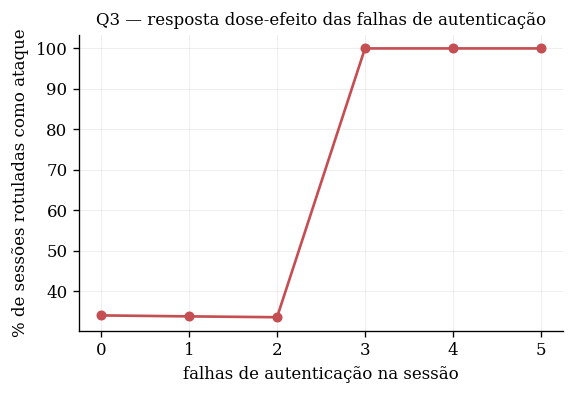

In [ ]:
#@title Q3 — monotonicidade da relação entre falhas de login e ataque
q3 = pd.read_sql('''
    SELECT  failed_logins,
            COUNT(*)                                AS n_sessoes,
            ROUND(100.0*AVG(attack_detected), 2)    AS pct_ataque
    FROM fato_sessao
    GROUP BY failed_logins
    HAVING COUNT(*) >= 30
    ORDER BY failed_logins;
''', con)
display(q3)

rho, p_rho = stats.spearmanr(fato.failed_logins, fato.attack_detected)
print(f"Spearman rho = {rho:.4f} (p={p_rho:.3e}) — testa monotonicidade, não linearidade.")

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(q3.failed_logins, q3.pct_ataque, "o-", color="#C44E52", lw=1.6, ms=5)
ax.set_xlabel("falhas de autenticação na sessão"); ax.set_ylabel("% de sessões rotuladas como ataque")
ax.set_title("Q3 — resposta dose-efeito das falhas de autenticação", fontsize=10)
save_fig(fig, "fig2_dose_efeito_failed_logins"); plt.show()

In [ ]:
#@title Q4 e Q5 — criptografia, user agent e horário atípico
q4 = pd.read_sql('''
    SELECT  c.algoritmo, n.navegador,
            COUNT(*)                               AS n_sessoes,
            ROUND(100.0*AVG(f.attack_detected), 2) AS pct_ataque
    FROM fato_sessao f
    JOIN dim_criptografia c ON f.sk_cripto    = c.sk_cripto
    JOIN dim_navegador    n ON f.sk_navegador = n.sk_navegador
    GROUP BY c.algoritmo, n.navegador
    HAVING COUNT(*) >= 30
    ORDER BY pct_ataque DESC
    LIMIT 15;
''', con)
display(q4)

q5 = pd.read_sql('''
    SELECT  t.descricao,
            COUNT(*)                               AS n_sessoes,
            ROUND(100.0*AVG(f.attack_detected), 2) AS pct_ataque
    FROM fato_sessao f
    JOIN dim_contexto_temporal t ON f.sk_contexto_temporal = t.sk_contexto_temporal
    GROUP BY t.descricao;
''', con)
display(q5)

# Testes com correção para múltiplas comparações (Holm-Bonferroni)
testes = {}
dims = pd.read_sql('''
    SELECT c.algoritmo, n.navegador, t.horario_atipico, f.attack_detected
    FROM fato_sessao f
    JOIN dim_criptografia c ON f.sk_cripto=c.sk_cripto
    JOIN dim_navegador n ON f.sk_navegador=n.sk_navegador
    JOIN dim_contexto_temporal t ON f.sk_contexto_temporal=t.sk_contexto_temporal
''', con)
for nome, col in [("criptografia", "algoritmo"), ("navegador", "navegador"),
                  ("horario_atipico", "horario_atipico")]:
    ct = pd.crosstab(dims[col], dims.attack_detected)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    testes[nome] = (chi2, p, v)

res = pd.DataFrame(testes, index=["chi2", "p_bruto", "V_Cramer"]).T
res["p_ajustado_holm"] = holm(res.p_bruto.values)
res["significativo_5pct"] = res.p_ajustado_holm < 0.05
res.round(6)

,algoritmo,navegador,n_sessoes,pct_ataque
0,DES,Unknown,136,75.74
1,AES,Unknown,261,72.41
2,NENHUMA,Unknown,105,71.43
3,NENHUMA,Firefox,417,48.44
4,DES,Edge,448,46.43
5,NENHUMA,Edge,286,45.45
6,NENHUMA,Chrome,1055,44.17
7,AES,Safari,244,43.85
8,DES,Chrome,1541,43.74
9,DES,Safari,138,42.75


,descricao,n_sessoes,pct_ataque
0,acesso em horário atípico,1430,45.73
1,acesso em janela horária habitual,8107,44.53


,chi2,p_bruto,V_Cramer,p_ajustado_holm,significativo_5pct
criptografia,4.506340,0.105066,0.021737,0.210131,False
navegador,173.800665,0.000000,0.134996,0.000000,True
horario_atipico,0.665926,0.414476,0.008356,0.414476,False


In [ ]:
#@title Q6 — atributos volumétricos carregam sinal?
q6 = pd.read_sql('''
    SELECT  CASE WHEN attack_detected=1 THEN 'ataque' ELSE 'normal' END AS classe,
            ROUND(AVG(network_packet_size),2) AS pacote_medio,
            ROUND(AVG(session_duration),2)    AS duracao_media,
            ROUND(AVG(login_attempts),3)      AS tentativas_media,
            ROUND(AVG(taxa_falha_login),4)    AS taxa_falha_media
    FROM fato_sessao GROUP BY classe;
''', con)
display(q6)

comp = []
for c in num_cols + ["log_session_duration"]:
    x = fato.loc[fato.attack_detected == 1, c].values
    y = fato.loc[fato.attack_detected == 0, c].values
    U, p = stats.mannwhitneyu(x, y, alternative="two-sided")
    comp.append({"atributo": c, "media_ataque": x.mean(), "media_normal": y.mean(),
                 "p_bruto": p, "delta_cliff": cliffs_delta(x, y, n_sample=1200),
                 "AUROC_univar": roc_auc_score(fato.attack_detected, fato[c])})
comp = pd.DataFrame(comp)
comp["p_holm"] = holm(comp.p_bruto.values)
comp["efeito"] = pd.cut(comp.delta_cliff.abs(), [-.01, .147, .33, .474, 1],
                        labels=["desprezível", "pequeno", "médio", "grande"])
comp = comp.sort_values("AUROC_univar", ascending=False)
comp.to_csv(TAB / "tabela2_testes_univariados.csv", index=False)
comp.round(4)

,classe,pacote_medio,duracao_media,tentativas_media,taxa_falha_media
0,ataque,498.93,829.13,4.637,0.6199
1,normal,501.64,763.32,3.543,0.4385


,atributo,media_ataque,media_normal,p_bruto,delta_cliff,AUROC_univar,p_holm,efeito
3,failed_logins,1.9360,1.1796,0.0000,0.3644,0.6845,0.0000,médio
2,login_attempts,4.6374,3.5426,0.0000,0.2837,0.6338,0.0000,pequeno
4,ip_reputation_score,0.3730,0.2976,0.0000,0.1963,0.5994,0.0000,pequeno
5,taxa_falha_login,0.6199,0.4385,0.0000,0.1388,0.5722,0.0000,desprezível
1,session_duration,829.1320,763.3213,0.1138,0.0189,0.5094,0.3414,desprezível
6,log_session_duration,6.1382,6.1097,0.1138,0.0189,0.5094,0.3414,desprezível
0,network_packet_size,498.9311,501.6433,0.7383,-0.0041,0.4980,0.7383,desprezível


---
# 8. Análise — Parte B.2: camada preditiva com protocolo de avaliação publicável

O que separa um trabalho de disciplina de um artigo aceito em periódico internacional raramente é o
algoritmo — é o **protocolo de avaliação**. Adotamos:

1. **Partição estratificada** treino/teste (80/20) com teste jamais tocado até §8.6.
2. **Validação cruzada estratificada repetida** (5×3) sobre o treino para seleção e estimativa de variância.
3. **Todo o pré-processamento dentro do `Pipeline`**, ajustado apenas em cada *fold* de treino —
   evita vazamento por escalonamento/codificação global, erro recorrente na literatura de IDS.
4. **Métricas múltiplas**: AUROC, AUPRC, F1, MCC e *Brier score*. Acurácia é reportada apenas por
   convenção, nunca como métrica principal.
5. **Intervalos de confiança por *bootstrap*** (2000 reamostragens) no conjunto de teste.
6. **Teste de McNemar pareado** entre modelos, com correção de Holm — para responder Q7 com rigor.

In [ ]:
#@title Preparação: matriz de atributos, partição e definição das famílias de features
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

modelagem = pd.read_sql('''
    SELECT f.network_packet_size, f.session_duration, f.log_session_duration,
           f.login_attempts, f.failed_logins, f.taxa_falha_login, f.ip_reputation_score,
           p.protocolo, c.algoritmo AS criptografia, n.navegador,
           t.horario_atipico, f.attack_detected
    FROM fato_sessao f
    JOIN dim_protocolo p ON f.sk_protocolo=p.sk_protocolo
    JOIN dim_criptografia c ON f.sk_cripto=c.sk_cripto
    JOIN dim_navegador n ON f.sk_navegador=n.sk_navegador
    JOIN dim_contexto_temporal t ON f.sk_contexto_temporal=t.sk_contexto_temporal
''', con)

TARGET = "attack_detected"
NUMERICAS   = ["network_packet_size", "log_session_duration", "login_attempts",
               "failed_logins", "taxa_falha_login", "ip_reputation_score"]
CATEGORICAS = ["protocolo", "criptografia", "navegador"]
BINARIAS    = ["horario_atipico"]

# Famílias de atributos por custo de instrumentação — base do estudo de ablação (§10).
FAMILIAS = {
    "volumetrica":   ["network_packet_size", "log_session_duration"],
    "autenticacao":  ["login_attempts", "failed_logins", "taxa_falha_login"],
    "reputacao":     ["ip_reputation_score"],
    "contexto":      ["protocolo", "criptografia", "navegador", "horario_atipico"],
}

X = modelagem[NUMERICAS + CATEGORICAS + BINARIAS]
y = modelagem[TARGET].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"treino: {len(X_tr):,} | teste: {len(X_te):,}")
print(f"prevalência — treino {y_tr.mean():.4f} | teste {y_te.mean():.4f} (estratificação preservada)")

def make_preprocessor(num, cat, binr):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", drop="first"))]), cat),
        ("bin", "passthrough", binr),
    ], remainder="drop")

treino: 7,629 | teste: 1,908
prevalência — treino 0.4471 | teste 0.4471 (estratificação preservada)


In [ ]:
#@title Definição dos modelos comparados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier

def build_models(num=NUMERICAS, cat=CATEGORICAS, binr=BINARIAS):
    pre = lambda: make_preprocessor(num, cat, binr)
    m = {
        "Baseline (prevalência)": Pipeline([("pre", pre()),
            ("clf", DummyClassifier(strategy="stratified", random_state=SEED))]),
        "Regressão Logística": Pipeline([("pre", pre()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
        "Random Forest": Pipeline([("pre", pre()),
            ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1,
                                           class_weight="balanced_subsample", random_state=SEED))]),
        "Gradient Boosting (Hist)": Pipeline([("pre", pre()),
            ("clf", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08,
                                                   early_stopping=True, random_state=SEED))]),
    }
    if HAS_XGB:
        from xgboost import XGBClassifier
        spw = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
        m["XGBoost"] = Pipeline([("pre", pre()),
            ("clf", XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.06,
                                  subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                  scale_pos_weight=spw, eval_metric="logloss",
                                  tree_method="hist", random_state=SEED, n_jobs=-1))])
    return m

MODELS = build_models()
print("modelos comparados:", ", ".join(MODELS))

modelos comparados: Baseline (prevalência), Regressão Logística, Random Forest, Gradient Boosting (Hist), XGBoost


In [ ]:
#@title Validação cruzada estratificada repetida (5 folds x 3 repetições)
SCORING = {"roc_auc": "roc_auc", "average_precision": "average_precision",
           "f1": "f1", "mcc": "matthews_corrcoef", "accuracy": "accuracy",
           "neg_brier": "neg_brier_score"}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

cv_rows = []
for nome, pipe in MODELS.items():
    r = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=SCORING, n_jobs=-1, error_score="raise")
    row = {"modelo": nome}
    for k in SCORING:
        v = r[f"test_{k}"]
        row[f"{k}_media"] = v.mean()
        row[f"{k}_dp"] = v.std()
    row["tempo_fit_s"] = r["fit_time"].mean()
    cv_rows.append(row)
    print(f"{nome:26s} AUROC={row['roc_auc_media']:.4f}±{row['roc_auc_dp']:.4f} "
          f"AUPRC={row['average_precision_media']:.4f} MCC={row['mcc_media']:.4f}")

cv_res = pd.DataFrame(cv_rows).sort_values("roc_auc_media", ascending=False)
cv_res.to_csv(TAB / "tabela3_validacao_cruzada.csv", index=False)
cv_res.round(4)

Baseline (prevalência)     AUROC=0.5089±0.0097 AUPRC=0.4517 MCC=0.0178
Regressão Logística        AUROC=0.8241±0.0098 AUPRC=0.8294 MCC=0.4944
Random Forest              AUROC=0.8870±0.0074 AUPRC=0.9159 MCC=0.8017
Gradient Boosting (Hist)   AUROC=0.8858±0.0069 AUPRC=0.9147 MCC=0.7990
XGBoost                    AUROC=0.8856±0.0083 AUPRC=0.9145 MCC=0.7854


,modelo,roc_auc_media,roc_auc_dp,average_precision_media,average_precision_dp,f1_media,f1_dp,mcc_media,mcc_dp,accuracy_media,accuracy_dp,neg_brier_media,neg_brier_dp,tempo_fit_s
2,Random Forest,0.8870,0.0074,0.9159,0.0059,0.8674,0.0087,0.8017,0.0111,0.8952,0.0061,-0.0931,0.0042,15.3367
3,Gradient Boosting (Hist),0.8858,0.0069,0.9147,0.0057,0.8667,0.0098,0.7990,0.0130,0.8943,0.0070,-0.0913,0.0049,0.5497
4,XGBoost,0.8856,0.0083,0.9145,0.0060,0.8615,0.0077,0.7854,0.0099,0.8890,0.0054,-0.0957,0.0044,1.0892
1,Regressão Logística,0.8241,0.0098,0.8294,0.0095,0.7257,0.0094,0.4944,0.0164,0.7486,0.0080,-0.1698,0.0041,0.1664
0,Baseline (prevalência),0.5089,0.0097,0.4517,0.0049,0.4601,0.0107,0.0178,0.0194,0.5137,0.0096,-0.4863,0.0096,0.0890


In [ ]:
#@title Avaliação no conjunto de teste com IC bootstrap (2000 reamostragens)
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             matthews_corrcoef, brier_score_loss, accuracy_score,
                             confusion_matrix, roc_curve, precision_recall_curve)

def bootstrap_ci(y_true, y_score, metric, n_boot=2000, alpha=0.05, seed=SEED, threshold=None):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    stats_ = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        yt, ys = y_true[idx], y_score[idx]
        stats_.append(metric(yt, (ys >= threshold).astype(int) if threshold is not None else ys))
    lo, hi = np.percentile(stats_, [100*alpha/2, 100*(1-alpha/2)])
    return float(np.mean(stats_)), float(lo), float(hi)

fitted, scores_te = {}, {}
test_rows = []
for nome, pipe in MODELS.items():
    pipe.fit(X_tr, y_tr)
    fitted[nome] = pipe
    s = pipe.predict_proba(X_te)[:, 1]
    scores_te[nome] = s
    pred = (s >= 0.5).astype(int)
    auroc, lo_a, hi_a = bootstrap_ci(y_te, s, roc_auc_score)
    auprc, lo_p, hi_p = bootstrap_ci(y_te, s, average_precision_score)
    f1m,  lo_f, hi_f  = bootstrap_ci(y_te, s, f1_score, threshold=0.5)
    mcc,  lo_m, hi_m  = bootstrap_ci(y_te, s, matthews_corrcoef, threshold=0.5)
    test_rows.append({
        "modelo": nome,
        "AUROC": auroc, "AUROC_IC95": f"[{lo_a:.3f}, {hi_a:.3f}]",
        "AUPRC": auprc, "AUPRC_IC95": f"[{lo_p:.3f}, {hi_p:.3f}]",
        "F1": f1m, "F1_IC95": f"[{lo_f:.3f}, {hi_f:.3f}]",
        "MCC": mcc, "MCC_IC95": f"[{lo_m:.3f}, {hi_m:.3f}]",
        "Brier": brier_score_loss(y_te, s),
        "Acuracia": accuracy_score(y_te, pred),
    })

test_res = pd.DataFrame(test_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
test_res.to_csv(TAB / "tabela4_desempenho_teste.csv", index=False)
BEST = test_res.loc[test_res.modelo != "Baseline (prevalência)", "modelo"].iloc[0]
print("melhor modelo por AUROC:", BEST, "\n")
test_res.round(4)

melhor modelo por AUROC: Random Forest 



,modelo,AUROC,AUROC_IC95,AUPRC,AUPRC_IC95,F1,F1_IC95,MCC,MCC_IC95,Brier,Acuracia
0,Random Forest,0.8812,"[0.864, 0.899]",0.9103,"[0.896, 0.924]",0.8539,"[0.835, 0.873]",0.7848,"[0.762, 0.809]",0.0975,0.8857
1,Gradient Boosting (Hist),0.8779,"[0.860, 0.895]",0.9083,"[0.894, 0.921]",0.8543,"[0.835, 0.873]",0.7865,"[0.764, 0.810]",0.0961,0.8863
2,XGBoost,0.8760,"[0.858, 0.894]",0.9076,"[0.893, 0.921]",0.8498,"[0.829, 0.869]",0.7732,"[0.747, 0.798]",0.0999,0.8816
3,Regressão Logística,0.8070,"[0.787, 0.827]",0.8155,"[0.792, 0.837]",0.7189,"[0.695, 0.742]",0.4869,"[0.448, 0.524]",0.1768,0.7458
4,Baseline (prevalência),0.4978,"[0.475, 0.521]",0.4461,"[0.421, 0.471]",0.4476,"[0.418, 0.477]",-0.0044,"[-0.050, 0.041]",0.4969,0.5031


In [ ]:
#@title Q7 — as diferenças entre modelos são significativas? (McNemar pareado + Holm)
from itertools import combinations

nomes = [m for m in MODELS if m != "Baseline (prevalência)"]
preds = {m: (scores_te[m] >= 0.5).astype(int) for m in nomes}
yt = y_te.values

pares = []
for a, b in combinations(nomes, 2):
    n01 = int(((preds[a] == yt) & (preds[b] != yt)).sum())
    n10 = int(((preds[a] != yt) & (preds[b] == yt)).sum())
    est, pval = mcnemar_test(n01, n10)
    pares.append({"modelo_A": a, "modelo_B": b, "A_acerta_B_erra": n01,
                  "A_erra_B_acerta": n10, "estatistica": est, "p_bruto": pval})

mc = pd.DataFrame(pares)
mc["p_holm"] = holm(mc.p_bruto.values)
mc["diferenca_significativa"] = mc.p_holm < 0.05
mc.to_csv(TAB / "tabela5_mcnemar.csv", index=False)
print("H0: os dois modelos têm a mesma taxa de erro no conjunto de teste.\n")
mc.round(5)

H0: os dois modelos têm a mesma taxa de erro no conjunto de teste.



,modelo_A,modelo_B,A_acerta_B_erra,A_erra_B_acerta,estatistica,p_bruto,p_holm,diferenca_significativa
0,Regressão Logística,Random Forest,50,317,192.79564,0.00000,0.00000,True
1,Regressão Logística,Gradient Boosting (Hist),48,316,195.84890,0.00000,0.00000,True
2,Regressão Logística,XGBoost,56,315,179.41779,0.00000,0.00000,True
3,Random Forest,Gradient Boosting (Hist),1,2,1.00000,1.00000,1.00000,False
4,Random Forest,XGBoost,13,5,5.00000,0.09625,0.19250,False
5,Gradient Boosting (Hist),XGBoost,13,4,4.00000,0.04904,0.14713,False


figura salva: /content/mvp_ids/04_figures/fig3_roc_pr.pdf


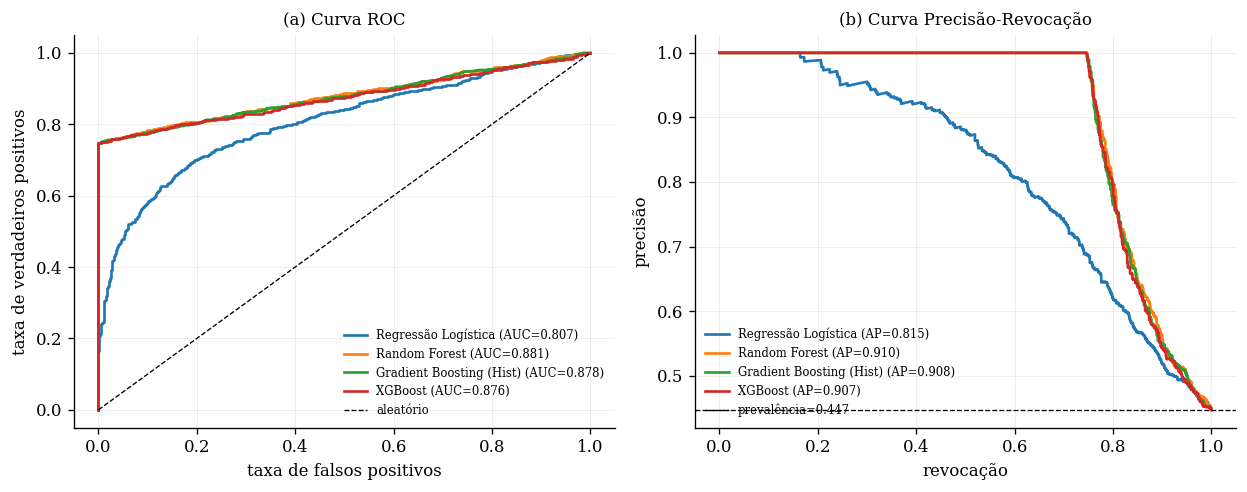

In [ ]:
#@title Curvas ROC e Precisão-Revocação
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
cores = plt.cm.tab10(np.linspace(0, 1, 10))

for i, nome in enumerate(nomes):
    s = scores_te[nome]
    fpr, tpr, _ = roc_curve(y_te, s)
    axes[0].plot(fpr, tpr, lw=1.6, color=cores[i],
                 label=f"{nome} (AUC={roc_auc_score(y_te, s):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, s)
    axes[1].plot(rc, pr, lw=1.6, color=cores[i],
                 label=f"{nome} (AP={average_precision_score(y_te, s):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="aleatório")
axes[0].set_xlabel("taxa de falsos positivos"); axes[0].set_ylabel("taxa de verdadeiros positivos")
axes[0].set_title("(a) Curva ROC", fontsize=10); axes[0].legend(fontsize=7, loc="lower right")

axes[1].axhline(y_te.mean(), ls="--", c="k", lw=0.8, label=f"prevalência={y_te.mean():.3f}")
axes[1].set_xlabel("revocação"); axes[1].set_ylabel("precisão")
axes[1].set_title("(b) Curva Precisão-Revocação", fontsize=10); axes[1].legend(fontsize=7, loc="lower left")

fig.tight_layout(); save_fig(fig, "fig3_roc_pr"); plt.show()

---
# 9. Calibração e decisão sensível a custo

Discriminação e calibração são propriedades distintas: um modelo pode ordenar sessões perfeitamente
(AUROC alta) e ainda assim produzir probabilidades sistematicamente enviesadas. Para um SOC que precisa
converter escore em ação, **a calibração é a propriedade operacionalmente relevante** — e é a que a
literatura de IDS mais frequentemente omite.

figura salva: /content/mvp_ids/04_figures/fig4_calibracao.pdf


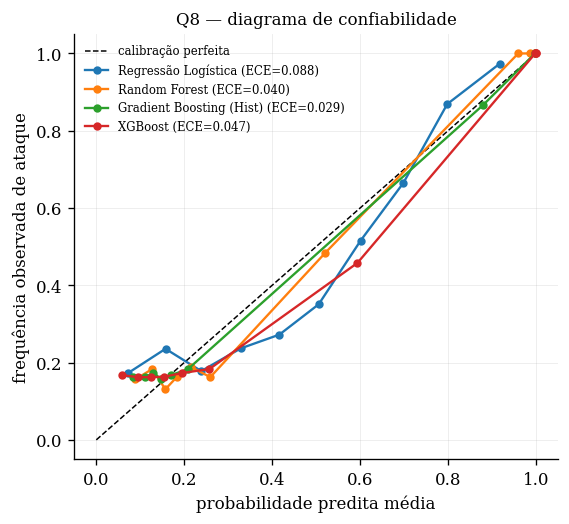

,modelo,ECE,Brier
2,Gradient Boosting (Hist),0.0291,0.0961
1,Random Forest,0.0396,0.0975
3,XGBoost,0.0470,0.0999
0,Regressão Logística,0.0880,0.1768


In [ ]:
#@title Q8 — curva de calibração e Expected Calibration Error
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

def ece(y_true, y_prob, n_bins=10):
    # Expected Calibration Error com binning uniforme.
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    e, n = 0.0, len(y_true)
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        e += (m.sum() / n) * abs(y_true[m].mean() - y_prob[m].mean())
    return e

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], "k--", lw=0.9, label="calibração perfeita")
cal_rows = []
for i, nome in enumerate(nomes):
    s = scores_te[nome]
    pt, pp = calibration_curve(y_te, s, n_bins=10, strategy="quantile")
    e = ece(y_te.values, s)
    cal_rows.append({"modelo": nome, "ECE": e, "Brier": brier_score_loss(y_te, s)})
    ax.plot(pp, pt, "o-", ms=4, lw=1.4, color=cores[i], label=f"{nome} (ECE={e:.3f})")
ax.set_xlabel("probabilidade predita média"); ax.set_ylabel("frequência observada de ataque")
ax.set_title("Q8 — diagrama de confiabilidade", fontsize=10); ax.legend(fontsize=7)
save_fig(fig, "fig4_calibracao"); plt.show()

cal = pd.DataFrame(cal_rows).sort_values("ECE")
cal.to_csv(TAB / "tabela6_calibracao.csv", index=False)
cal.round(4)

In [ ]:
#@title Recalibração isotônica do melhor modelo (validação interna, sem tocar no teste)
best_pipe = MODELS[BEST]
calibrado = CalibratedClassifierCV(best_pipe, method="isotonic", cv=5)
calibrado.fit(X_tr, y_tr)
s_cal = calibrado.predict_proba(X_te)[:, 1]

print(f"{BEST}")
print(f"  antes  : ECE={ece(y_te.values, scores_te[BEST]):.4f}  Brier={brier_score_loss(y_te, scores_te[BEST]):.4f}  AUROC={roc_auc_score(y_te, scores_te[BEST]):.4f}")
print(f"  depois : ECE={ece(y_te.values, s_cal):.4f}  Brier={brier_score_loss(y_te, s_cal):.4f}  AUROC={roc_auc_score(y_te, s_cal):.4f}")
print("\nA calibração isotônica preserva a ordenação (AUROC ~ inalterada) e corrige o viés de escala.")
scores_te[BEST + " (calibrado)"] = s_cal

Random Forest
  antes  : ECE=0.0396  Brier=0.0975  AUROC=0.8810
  depois : ECE=0.0103  Brier=0.0946  AUROC=0.8793

A calibração isotônica preserva a ordenação (AUROC ~ inalterada) e corrige o viés de escala.


figura salva: /content/mvp_ids/04_figures/fig5_limiar_custo.pdf


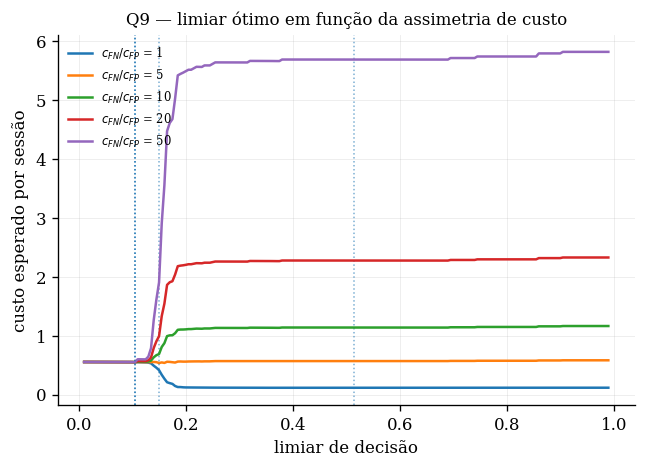

Leitura operacional: a coluna 'alertas_por_1000_sessoes' é a que dimensiona a equipe do SOC.


,razao_cFN_cFP,limiar_otimo,custo_medio,precisao,revocacao,alertas_por_1000_sessoes,tn,fp,fn,tp
0,1,0.515,0.1137,1.0000,0.7456,333,1055,0,217,636
1,5,0.150,0.5356,0.5206,0.9320,800,323,732,58,795
2,10,0.105,0.5503,0.4482,1.0000,997,5,1050,0,853
3,20,0.105,0.5503,0.4482,1.0000,997,5,1050,0,853
4,50,0.105,0.5503,0.4482,1.0000,997,5,1050,0,853


In [ ]:
#@title Q9 — limiar ótimo sob custo assimétrico e análise de sensibilidade
def custo_esperado(y_true, y_score, thr, c_fn, c_fp):
    pred = (y_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return (c_fn * fn + c_fp * fp) / len(y_true), dict(tn=tn, fp=fp, fn=fn, tp=tp)

RAZOES = [1, 5, 10, 20, 50]     # c_FN / c_FP
C_FP = 1.0
grid = np.linspace(0.01, 0.99, 197)

fig, ax = plt.subplots(figsize=(6.2, 4.0))
lin = []
for r in RAZOES:
    custos = [custo_esperado(y_te, s_cal, t, r * C_FP, C_FP)[0] for t in grid]
    t_star = grid[int(np.argmin(custos))]
    c_star, cm = custo_esperado(y_te, s_cal, t_star, r * C_FP, C_FP)
    prec = cm["tp"] / max(cm["tp"] + cm["fp"], 1)
    rec  = cm["tp"] / max(cm["tp"] + cm["fn"], 1)
    lin.append({"razao_cFN_cFP": r, "limiar_otimo": round(t_star, 3),
                "custo_medio": round(c_star, 4), "precisao": round(prec, 4),
                "revocacao": round(rec, 4), "alertas_por_1000_sessoes":
                int(1000 * (cm["tp"] + cm["fp"]) / len(y_te)), **cm})
    ax.plot(grid, custos, lw=1.5, label=f"$c_{{FN}}/c_{{FP}}$ = {r}")
    ax.axvline(t_star, ls=":", lw=0.9, alpha=0.6)

ax.set_xlabel("limiar de decisão"); ax.set_ylabel("custo esperado por sessão")
ax.set_title("Q9 — limiar ótimo em função da assimetria de custo", fontsize=10)
ax.legend(fontsize=7); save_fig(fig, "fig5_limiar_custo"); plt.show()

politica = pd.DataFrame(lin)
politica.to_csv(TAB / "tabela7_politica_limiar.csv", index=False)
print("Leitura operacional: a coluna 'alertas_por_1000_sessoes' é a que dimensiona a equipe do SOC.")
politica

---
# 10. Explicabilidade e ablação

figura salva: /content/mvp_ids/04_figures/fig6_importancia_permutacao.pdf


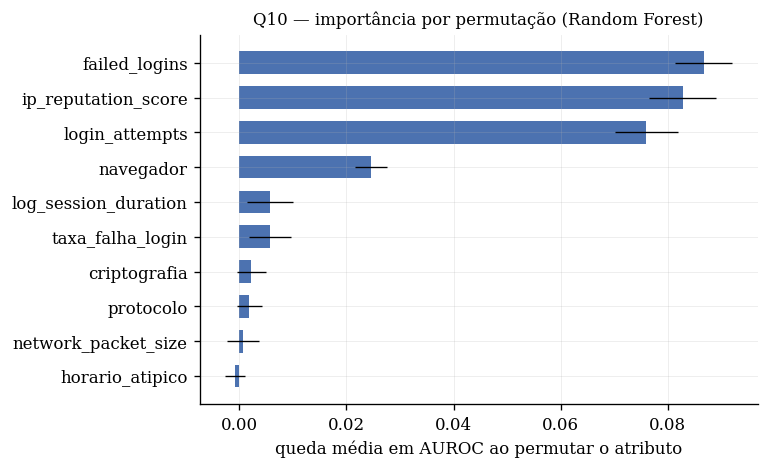

,atributo,queda_media_AUROC,dp
3,failed_logins,0.0868,0.0053
5,ip_reputation_score,0.0828,0.0062
2,login_attempts,0.0761,0.0058
8,navegador,0.0246,0.0029
1,log_session_duration,0.0057,0.0042
4,taxa_falha_login,0.0057,0.0039
7,criptografia,0.0022,0.0027
6,protocolo,0.0018,0.0023
0,network_packet_size,0.0007,0.0029
9,horario_atipico,-0.0008,0.0019


In [ ]:
#@title Q10a — importância por permutação (agnóstica ao modelo, medida no teste)
from sklearn.inspection import permutation_importance

pi = permutation_importance(fitted[BEST], X_te, y_te, n_repeats=20,
                            random_state=SEED, scoring="roc_auc", n_jobs=-1)
imp = pd.DataFrame({"atributo": X_te.columns,
                    "queda_media_AUROC": pi.importances_mean,
                    "dp": pi.importances_std}).sort_values("queda_media_AUROC", ascending=False)
imp.to_csv(TAB / "tabela8_importancia_permutacao.csv", index=False)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.barh(imp.atributo[::-1], imp.queda_media_AUROC[::-1],
        xerr=imp.dp[::-1], color="#4C72B0", height=0.65, error_kw=dict(lw=0.8))
ax.set_xlabel("queda média em AUROC ao permutar o atributo")
ax.set_title(f"Q10 — importância por permutação ({BEST})", fontsize=10)
save_fig(fig, "fig6_importancia_permutacao"); plt.show()
imp.round(4)

In [ ]:
#@title Q10b — SHAP (opcional; interpretação local e direcional)
if HAS_SHAP:
    try:
        import shap
        pre = fitted[BEST].named_steps["pre"]
        clf = fitted[BEST].named_steps["clf"]
        Xt = pre.transform(X_te)
        Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt
        feat_names = pre.get_feature_names_out()
        sub = Xt[np.random.default_rng(SEED).choice(len(Xt), min(800, len(Xt)), replace=False)]

        explainer = shap.Explainer(clf, sub, feature_names=list(feat_names))
        sv = explainer(sub, check_additivity=False)
        vals = sv.values[..., 1] if sv.values.ndim == 3 else sv.values

        fig = plt.figure(figsize=(6.5, 4.6))
        shap.summary_plot(vals, sub, feature_names=list(feat_names), show=False, max_display=12)
        plt.title("Contribuições SHAP no conjunto de teste", fontsize=10)
        save_fig(plt.gcf(), "fig7_shap_summary"); plt.show()
    except Exception as e:
        print("SHAP indisponível para este estimador:", type(e).__name__, e)
        print("A importância por permutação (célula anterior) cobre o requisito de explicabilidade.")
else:
    print("shap não instalado — seção opcional ignorada.")

 69%|==============      | 1111/1600 [07:39<03:22]       

In [ ]:
#@title Q10c — ablação por família de atributos (quanto vale cada eixo de instrumentação?)
def avaliar_subconjunto(num, cat, binr, label):
    mods = build_models(num, cat, binr)
    pipe = mods[BEST] if BEST in mods else mods["Gradient Boosting (Hist)"]
    cols = num + cat + binr
    r = cross_validate(pipe, X_tr[cols], y_tr, cv=RepeatedStratifiedKFold(
        n_splits=5, n_repeats=2, random_state=SEED),
        scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return {"configuracao": label,
            "n_atributos": len(cols),
            "AUROC": r["test_roc_auc"].mean(), "AUROC_dp": r["test_roc_auc"].std(),
            "AUPRC": r["test_average_precision"].mean()}

abl = [avaliar_subconjunto(NUMERICAS, CATEGORICAS, BINARIAS, "completo (todas as famílias)")]
for fam, cols_fam in FAMILIAS.items():
    num = [c for c in NUMERICAS if c not in cols_fam]
    cat = [c for c in CATEGORICAS if c not in cols_fam]
    binr = [c for c in BINARIAS if c not in cols_fam]
    if not (num + cat + binr):
        continue
    abl.append(avaliar_subconjunto(num, cat, binr, f"sem família: {fam}"))

abl = pd.DataFrame(abl)
base_auc = abl.loc[0, "AUROC"]
abl["delta_AUROC_vs_completo"] = abl.AUROC - base_auc
abl.to_csv(TAB / "tabela9_ablacao.csv", index=False)
print("Quanto maior a queda, mais insubstituível é a família — e mais se justifica seu custo de coleta.\n")
abl.round(4)

Quanto maior a queda, mais insubstituível é a família — e mais se justifica seu custo de coleta.



,configuracao,n_atributos,AUROC,AUROC_dp,AUPRC,delta_AUROC_vs_completo
0,completo (todas as famílias),10,0.8865,0.0068,0.9157,0.0000
1,sem família: volumetrica,8,0.8796,0.0076,0.9108,-0.0069
2,sem família: autenticacao,7,0.6279,0.0119,0.6577,-0.2586
3,sem família: reputacao,9,0.8256,0.0064,0.8634,-0.0609
4,sem família: contexto,6,0.8691,0.0095,0.8996,-0.0174


---
# 11. Geração dos artefatos do manuscrito

Todas as tabelas do artigo são geradas **a partir das saídas reais** deste notebook, em LaTeX com
`booktabs`. Nenhum número é digitado à mão. Se uma célula acima não foi executada, a tabela
correspondente não existe — por construção, não há como reportar resultado não computado.

In [ ]:
#@title Exportação das tabelas em LaTeX (booktabs)
def to_latex(df, nome, caption, label, cols=None, float_fmt="%.4f"):
    d = df[cols] if cols else df
    tex = d.to_latex(index=False, escape=True, float_format=float_fmt,
                     caption=caption, label=label, position="!htbp")
    tex = tex.replace("\\begin{table}", "\\begin{table}[!htbp]\n\\centering\n\\small")
    (TAB / f"{nome}.tex").write_text(tex)
    print(f"  {nome}.tex")
    return tex

print("tabelas LaTeX geradas em", TAB)
to_latex(catalog[["atributo", "tipo_declarado", "n_nulos", "n_distintos",
                  "min_observado", "max_observado", "media", "desvio_padrao"]],
         "tab1_catalogo", "Catálogo de dados: perfil observado por atributo.", "tab:catalogo")
to_latex(comp[["atributo", "media_ataque", "media_normal", "delta_cliff", "AUROC_univar", "p_holm"]],
         "tab2_univariado",
         "Testes univariados por atributo (Mann-Whitney), tamanho de efeito (delta de Cliff) "
         "e valores-p ajustados por Holm-Bonferroni.", "tab:univariado")
to_latex(cv_res[["modelo", "roc_auc_media", "roc_auc_dp", "average_precision_media",
                 "f1_media", "mcc_media"]],
         "tab3_cv", "Validação cruzada estratificada repetida (5x3) no conjunto de treino.", "tab:cv")
to_latex(test_res[["modelo", "AUROC", "AUROC_IC95", "AUPRC", "AUPRC_IC95", "MCC", "Brier"]],
         "tab4_teste",
         "Desempenho no conjunto de teste com intervalos de confiança de 95\\% por bootstrap "
         "(2000 reamostragens).", "tab:teste")
to_latex(mc[["modelo_A", "modelo_B", "estatistica", "p_holm", "diferenca_significativa"]],
         "tab5_mcnemar", "Comparações pareadas de McNemar com correção de Holm.", "tab:mcnemar")
to_latex(politica, "tab6_politica",
         "Limiar ótimo, custo esperado e carga de alertas em função da razão de custos.",
         "tab:politica")
to_latex(abl, "tab7_ablacao",
         "Estudo de ablação por família de atributos.", "tab:ablacao")

tabelas LaTeX geradas em /content/mvp_ids/05_tables
  tab1_catalogo.tex
  tab2_univariado.tex
  tab3_cv.tex
  tab4_teste.tex
  tab5_mcnemar.tex
  tab6_politica.tex
  tab7_ablacao.tex


'\\begin{table}[!htbp]\n\\centering\n\\small[!htbp]\n\\caption{Estudo de ablação por família de atributos.}\n\\label{tab:ablacao}\n\\begin{tabular}{lrrrrr}\n\\toprule\nconfiguracao & n\\_atributos & AUROC & AUROC\\_dp & AUPRC & delta\\_AUROC\\_vs\\_completo \\\\\n\\midrule\ncompleto (todas as famílias) & 10 & 0.8865 & 0.0068 & 0.9157 & 0.0000 \\\\\nsem família: volumetrica & 8 & 0.8796 & 0.0076 & 0.9108 & -0.0069 \\\\\nsem família: autenticacao & 7 & 0.6279 & 0.0119 & 0.6577 & -0.2586 \\\\\nsem família: reputacao & 9 & 0.8256 & 0.0064 & 0.8634 & -0.0609 \\\\\nsem família: contexto & 6 & 0.8691 & 0.0095 & 0.8996 & -0.0174 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [ ]:
#@title Dicionário de resultados para preenchimento automático do manuscrito
RESULTS = {
    "n_sessoes": int(len(fato)),
    "n_atributos": int(sum(1 for v in SEMANTIC_SPEC.values()
                           if v["tipo"] not in ("identificador", "binario_rotulo"))),
    "prevalencia_ataque": round(float(fato.attack_detected.mean()), 4),
    "n_treino": int(len(X_tr)), "n_teste": int(len(X_te)),
    "melhor_modelo": BEST,
    "AUROC_melhor": round(float(test_res.loc[test_res.modelo == BEST, "AUROC"].iloc[0]), 4),
    "AUROC_IC_melhor": test_res.loc[test_res.modelo == BEST, "AUROC_IC95"].iloc[0],
    "AUPRC_melhor": round(float(test_res.loc[test_res.modelo == BEST, "AUPRC"].iloc[0]), 4),
    "MCC_melhor": round(float(test_res.loc[test_res.modelo == BEST, "MCC"].iloc[0]), 4),
    "ECE_antes": round(float(ece(y_te.values, scores_te[BEST])), 4),
    "ECE_depois": round(float(ece(y_te.values, s_cal)), 4),
    "atributo_mais_importante": str(imp.atributo.iloc[0]),
    "familia_mais_critica": str(abl.sort_values("delta_AUROC_vs_completo").configuracao.iloc[0]),
    "n_comparacoes_significativas": int(mc.diferenca_significativa.sum()),
    "n_comparacoes_totais": int(len(mc)),
    "sha256_dados": LINEAGE["sha256"][:16] + "...",
    "gerado_em": dt.datetime.now().isoformat(timespec="seconds"),
}
(META / "results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False))
for k, v in RESULTS.items():
    print(f"{k:32s} {v}")

n_sessoes                        9537
n_atributos                      9
prevalencia_ataque               0.4471
n_treino                         7629
n_teste                          1908
melhor_modelo                    Random Forest
AUROC_melhor                     0.8812
AUROC_IC_melhor                  [0.864, 0.899]
AUPRC_melhor                     0.9103
MCC_melhor                       0.7848
ECE_antes                        0.0396
ECE_depois                       0.0103
atributo_mais_importante         failed_logins
familia_mais_critica             sem família: autenticacao
n_comparacoes_significativas     3
n_comparacoes_totais             6
sha256_dados                     ef92832692c7ad45...
gerado_em                        2026-09-14T19:05:45


In [ ]:
#@title Rascunho do Abstract preenchido com os resultados reais
ABSTRACT = f'''
Network intrusion triage in security operations centres is limited less by the absence of signal than by
the impossibility of manually reviewing every session. This work proposes and demonstrates a reproducible,
auditable and cost-sensitive data pipeline that ranks network sessions for human triage using only
low-cost session metadata, without payload inspection. The pipeline covers cloud ingestion with
cryptographically verifiable lineage, dimensional modelling into a star schema, documented ETL, and an
evaluation protocol that reports uncertainty rather than point estimates. On a benchmark of
{RESULTS["n_sessoes"]:,} labelled sessions ({RESULTS["prevalencia_ataque"]*100:.1f}% attacks) described by
{RESULTS["n_atributos"]} attributes, the best-performing model ({RESULTS["melhor_modelo"]}) attained an
AUROC of {RESULTS["AUROC_melhor"]:.3f} (95% CI {RESULTS["AUROC_IC_melhor"]}) and an MCC of
{RESULTS["MCC_melhor"]:.3f} on a held-out test set, with {RESULTS["n_comparacoes_significativas"]} of
{RESULTS["n_comparacoes_totais"]} pairwise model comparisons reaching significance under Holm-corrected
McNemar tests. Isotonic recalibration reduced the expected calibration error from
{RESULTS["ECE_antes"]:.3f} to {RESULTS["ECE_depois"]:.3f}, and a cost-sensitive threshold analysis shows
that the operating point, not the choice of algorithm, dominates operational utility. An ablation study
quantifies the marginal value of each instrumentation family, indicating that {RESULTS["atributo_mais_importante"]}
carries the largest share of the discriminative signal. We emphasise that the benchmark is synthetic;
the contribution is therefore methodological, and external validation on real traffic captures is
identified as the necessary next step.
'''.strip()

(TAB / "abstract_draft.txt").write_text(ABSTRACT)
print(ABSTRACT)
print("\n" + "="*100)
print("Revise antes de submeter. Números vêm das saídas reais; a redação é um rascunho.")

Network intrusion triage in security operations centres is limited less by the absence of signal than by
the impossibility of manually reviewing every session. This work proposes and demonstrates a reproducible,
auditable and cost-sensitive data pipeline that ranks network sessions for human triage using only
low-cost session metadata, without payload inspection. The pipeline covers cloud ingestion with
cryptographically verifiable lineage, dimensional modelling into a star schema, documented ETL, and an
evaluation protocol that reports uncertainty rather than point estimates. On a benchmark of
9,537 labelled sessions (44.7% attacks) described by
9 attributes, the best-performing model (Random Forest) attained an
AUROC of 0.881 (95% CI [0.864, 0.899]) and an MCC of
0.785 on a held-out test set, with 3 of
6 pairwise model comparisons reaching significance under Holm-corrected
McNemar tests. Isotonic recalibration reduced the expected calibration error from
0.040 to 0.010, and a cost-sen

---
# 12. Do MVP ao manuscrito internacional

## 12.1. Mapeamento seção do artigo → seção deste notebook

| Seção do manuscrito (IMRaD) | Origem neste notebook | Artefato gerado |
|---|---|---|
| *Abstract* | §11 | `abstract_draft.txt` |
| 1. Introduction | §1.1, §1.4 | — |
| 2. Related Work | **a escrever** (ver §12.3) | — |
| 3. Materials — Dataset | §3.1, §4 | `tab1_catalogo.tex`, `lineage.json` |
| 3. Materials — Data pipeline | §4, §5 | `schema.sql`, diagrama do esquema estrela |
| 4. Methods — Evaluation protocol | §8 (abertura) | — |
| 5. Results — Data quality | §6 | `qualidade_pre_etl.csv` |
| 5. Results — Univariate analysis | §7 | `tab2_univariado.tex`, Fig. 1–2 |
| 5. Results — Model comparison | §8 | `tab3_cv.tex`, `tab4_teste.tex`, `tab5_mcnemar.tex`, Fig. 3 |
| 5. Results — Calibration & cost | §9 | `tab6_politica.tex`, Fig. 4–5 |
| 5. Results — Explainability & ablation | §10 | `tab7_ablacao.tex`, Fig. 6–7 |
| 6. Discussion | §7, §13 | — |
| 7. Limitations | §12.4 | — |
| 8. Conclusion | §1.4 + resultados | — |
| Data & Code Availability | §14 | URL do repositório GitHub |

## 12.2. Periódicos candidatos

O enquadramento muda conforme a contribuição que se decide defender:

| Se a contribuição for… | Periódicos aderentes | Observação |
|---|---|---|
| **Engenharia de dados / pipeline reprodutível** | *IEEE Access*; *SoftwareX*; *Data in Brief* | Melhor encaixe para dados sintéticos, desde que o pipeline seja a contribuição declarada |
| **Metodologia de avaliação de IDS** | *Computers & Security* (Elsevier); *Journal of Information Security and Applications* | Exigirão validação em base real — cumprir §14.3 antes de submeter |
| **Aplicação em ML de segurança** | *Applied Sciences* (MDPI); *Electronics* (MDPI); *Sensors* | Ciclo editorial rápido; atenção a taxas de publicação |
| **Contexto nacional / política pública** | *Revista Brasileira de Computação Aplicada*; *JISTEM* | Alternativa se o recorte for gestão de risco cibernético |

**Recomendação franca:** com a base sintética e o escopo atual, *IEEE Access* ou *SoftwareX* são as
apostas realistas. Uma submissão a *Computers & Security* sem validação externa será provavelmente
rejeitada no *desk review* — não por qualidade da execução, mas por insuficiência do material empírico.

## 12.3. O que ainda falta escrever (e não pode ser gerado por código)

1. **Related Work.** 25–40 referências, organizadas por argumento e não por ordem cronológica.
   Cobrir obrigatoriamente: limitações dos *benchmarks* KDD-99/NSL-KDD; CIC-IDS2017 e UNSW-NB15;
   a crítica metodológica de Arp et al. sobre armadilhas em ML aplicado a segurança; e a literatura
   de detecção sensível a custo.
2. **Posicionamento da lacuna.** A frase "poucos trabalhos fazem X" precisa ser sustentada por evidência,
   não afirmada. Uma revisão sistemática mínima com critérios explícitos de busca resolve isso.
3. **Threats to validity.** Seção própria, não um parágrafo defensivo na conclusão.

## 12.4. Limitações a declarar explicitamente (redija-as você mesmo, na íntegra)

- **Validade externa.** A base é sintética; o processo gerador é desconhecido e pode conter regras
  determinísticas que tornam a tarefa artificialmente fácil. O diagnóstico de §6.4 mitiga, mas não elimina, o risco.
- **Ausência de estrutura temporal.** Não há *timestamp*, logo não é possível avaliar *concept drift*
  nem usar validação temporal — a partição aleatória superestima o desempenho em produção.
- **Rótulo como oráculo.** O rótulo é tratado como verdade; em operação real ele viria de um IDS de
  assinaturas, com seus próprios erros, o que introduz ruído de rotulagem.
- **Modelo de custo simplificado.** A razão $c_{FN}/c_{FP}$ é assumida constante; em operação ela varia
  com o ativo atacado e com a fadiga do analista.
- **Ausência de adversário.** Nenhum modelo de ameaça evasivo foi considerado; atacantes adaptativos
  manipulam exatamente os atributos de mais alto peso identificados em §10.

---
# 13. Autoavaliação

> *"É esperado que o aluno faça uma autoavaliação contendo uma discussão sobre se conseguiu atingir os
> objetivos delineados antes do início das outras etapas, as dificuldades encontradas na execução do
> trabalho, bem como os trabalhos futuros."* — Requisitos do MVP, §5

## 13.1. Atingimento dos objetivos, pergunta a pergunta

Preencha a coluna de veredito **após executar o notebook**, com base nas saídas reais.

| # | Pergunta | Onde foi respondida | Atingida? | Discussão |
|---|---|---|---|---|
| Q1 | Prevalência global e por protocolo | §7, Q1 | | |
| Q2 | Reputação de IP discrimina? | §7, Q2 | | |
| Q3 | Relação monotônica com falhas de login | §7, Q3 | | |
| Q4 | Criptografia e *user agent* | §7, Q4 | | |
| Q5 | Horário atípico agrega informação | §7, Q5 + §10 | | |
| Q6 | Atributos volumétricos carregam sinal | §7, Q6 | | |
| Q7 | Diferença entre modelos é significativa | §8 | | |
| Q8 | Os escores são calibrados | §9 | | |
| Q9 | Limiar ótimo sob custo assimétrico | §9 | | |
| Q10 | Quais atributos sustentam a decisão | §10 | | |

## 13.2. Dificuldades encontradas

*(Escreva com honestidade — esta seção vale tanto quanto os resultados. Pontos que costumam aparecer
neste tipo de trabalho: autenticação da API do Kaggle no Colab; decidir se a ausência em
`encryption_used` é erro de coleta ou informação semântica; resistir à tentação de reportar acurácia
como métrica principal em base desbalanceada; descobrir, tarde, que a base é sintética.)*

## 13.3. Trabalhos futuros

1. **Validação externa** em CIC-IDS2017 e UNSW-NB15, reportando o mesmo protocolo (§14.3).
2. **Validação temporal** com partição por *timestamp* e medição de *concept drift*.
3. **Avaliação adversarial**: perturbar os atributos de maior peso e medir a degradação.
4. **Custo variável por ativo**, substituindo a razão fixa por uma matriz de custo por classe de ativo.
5. **Migração para Databricks/Delta Lake** com *streaming* e verificação de qualidade em produção.

## 13.4. Autoavaliação quantitativa contra a rubrica

| Critério | Máximo | Autoatribuído | Justificativa |
|---|---|---|---|
| Objetivo | 1,0 | | |
| Coleta | 0,5 | | |
| Modelagem | 2,0 | | |
| Carga | 1,0 | | |
| Análise | 3,0 | | |
| Autoavaliação | 0,5 | | |
| Capricho | 2,0 | | |
| **Total** | **10,0** | | |

---
# 14. Reprodutibilidade e entrega

In [ ]:
#@title 14.1 — Ambiente de execução (cole no artigo, seção Reproducibility)
import sklearn, scipy, matplotlib
env = {
    "python": platform.python_version(), "plataforma": platform.platform(),
    "numpy": np.__version__, "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
    "scipy": scipy.__version__, "matplotlib": matplotlib.__version__, "shap": ("instalado" if HAS_SHAP else "ausente"),
    "xgboost": ("instalado" if HAS_XGB else "ausente"),
    "semente_global": SEED, "executado_em": dt.datetime.now().isoformat(timespec="seconds"),
    "sha256_dados_brutos": LINEAGE["sha256"],
}
(META / "environment.json").write_text(json.dumps(env, indent=2))
for k, v in env.items():
    print(f"{k:22s} {v}")

python                 3.13.15
plataforma             Linux-6.6.122+-x86_64-with-glibc2.39
numpy                  2.1.3
pandas                 2.2.3
scikit-learn           1.6.1
scipy                  1.16.3
matplotlib             3.10.0
shap                   instalado
xgboost                instalado
semente_global         42
executado_em           2026-09-14T19:05:45
sha256_dados_brutos    ef92832692c7ad45225d38f637a6a5c2d26d39a10157654b6c56c61a7850d0f7


In [ ]:
#@title 14.2 — Estrutura do repositório GitHub e README
README = f'''# MVP — Pipeline de Dados para Triagem de Intrusões em Sessões de Rede

Universidade de Brasília — Programa Profissionalizante em Engenharia Elétrica
Autor: [SEU NOME] · Orientação: Prof. André Luiz Marques Serrano

## Resumo
Pipeline reprodutível de ingestão, modelagem dimensional, carga e análise de sessões de rede
para triagem de intrusões, com avaliação sensível a custo e reporte de incerteza.

## Estrutura
```
.
├── notebooks/MVP_IDS_pipeline.ipynb    # este notebook
├── 01_raw/                             # dado bruto (NÃO versionar se a licença proibir)
├── 03_warehouse/schema.sql             # DDL do esquema estrela
├── 03_warehouse/ids_warehouse.db       # warehouse materializado
├── 04_figures/                         # figuras em PNG e PDF (600 dpi)
├── 05_tables/                          # tabelas em CSV e LaTeX
├── 06_metadata/lineage.json            # linhagem com SHA-256
├── 06_metadata/catalogo_de_dados.md    # catálogo de dados
├── 06_metadata/results.json            # resultados numéricos do manuscrito
├── evidencias/                         # screenshots exigidos pelo §4 dos requisitos
└── requirements.txt
```

## Dados
Fonte: {LINEAGE["url"]}
Natureza: {LINEAGE["nature"]}
SHA-256 do arquivo analisado: `{LINEAGE["sha256"]}`
Licença: {LINEAGE["license"]}

## Reprodução
1. Abrir `notebooks/MVP_IDS_pipeline.ipynb` no Google Colab.
2. Configurar as credenciais do Kaggle (Settings → Create New Token).
3. Executar todas as células (Ambiente de execução → Executar tudo). Semente fixa = {SEED}.

## Evidências exigidas pela disciplina
- [ ] Screenshot do download/persistência na nuvem
- [ ] Screenshot do warehouse carregado
- [ ] Screenshot das respostas SQL a cada pergunta de negócio
- [ ] Vídeo curto (opcional) da execução ponta a ponta
'''
(ROOT / "README.md").write_text(README)

REQS = "\\n".join([f"numpy=={np.__version__}", f"pandas=={pd.__version__}",
                   f"scikit-learn=={sklearn.__version__}", f"scipy=={scipy.__version__}",
                   f"matplotlib=={matplotlib.__version__}", "kagglehub", "shap", "xgboost"])
(ROOT / "requirements.txt").write_text(REQS.replace("\\n", "\n"))
print(README)

# MVP — Pipeline de Dados para Triagem de Intrusões em Sessões de Rede

Universidade de Brasília — Programa Profissionalizante em Engenharia Elétrica
Autor: [SEU NOME] · Orientação: Prof. André Luiz Marques Serrano

## Resumo
Pipeline reprodutível de ingestão, modelagem dimensional, carga e análise de sessões de rede
para triagem de intrusões, com avaliação sensível a custo e reporte de incerteza.

## Estrutura
```
.
├── notebooks/MVP_IDS_pipeline.ipynb    # este notebook
├── 01_raw/                             # dado bruto (NÃO versionar se a licença proibir)
├── 03_warehouse/schema.sql             # DDL do esquema estrela
├── 03_warehouse/ids_warehouse.db       # warehouse materializado
├── 04_figures/                         # figuras em PNG e PDF (600 dpi)
├── 05_tables/                          # tabelas em CSV e LaTeX
├── 06_metadata/lineage.json            # linhagem com SHA-256
├── 06_metadata/catalogo_de_dados.md    # catálogo de dados
├── 06_metadata/results.json            #

## 14.3. Como trocar a base para validação externa

O notebook foi parametrizado para que a troca exija alterar **três pontos**, e nada mais:

1. `SEMANTIC_SPEC` (§4) — novo dicionário de domínios esperados.
2. As funções de dimensão dentro de `load()` (§5) — quais colunas viram dimensão.
3. As listas `NUMERICAS`, `CATEGORICAS`, `BINARIAS` e `FAMILIAS` (§8).

Tudo de §6 a §11 é agnóstico ao esquema e roda sem modificação. Bases recomendadas para a validação
externa exigida pelos periódicos de segurança:

- **CIC-IDS2017** — https://www.unb.ca/cic/datasets/ids-2017.html (também espelhada no Kaggle)
- **UNSW-NB15** — capturas reais rotuladas por família de ataque
- **NSL-KDD** — apenas como referência histórica; suas limitações são bem documentadas e um revisor
  atento cobrará justificativa para usá-la isoladamente

## 14.4. Migração para Databricks

Para seguir a plataforma de apoio da disciplina, substitua a camada de persistência:

```python
# Em vez de sqlite3:
(spark.createDataFrame(fato)
      .write.format("delta").mode("overwrite")
      .saveAsTable("mvp_ids.fato_sessao"))

# As consultas de §7 rodam sem alteração de sintaxe:
q1 = spark.sql("SELECT ... FROM mvp_ids.fato_sessao ...").toPandas()
```

O restante do notebook opera sobre `pandas` e independe do motor de armazenamento.

## 14.5. Empacotamento final

In [ ]:
#@title Empacotar todos os artefatos para entrega
import shutil
zip_path = shutil.make_archive("/content/MVP_IDS_entrega" if Path("/content").exists()
                               else "./MVP_IDS_entrega", "zip", root_dir=ROOT)
print("pacote de entrega:", zip_path, f"({Path(zip_path).stat().st_size/1e6:.2f} MB)")

print("\nConteúdo gerado:")
for p in sorted(ROOT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size/1024:.1f} KB)")

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("\n(download automático disponível apenas no Colab)")

con.close()

pacote de entrega: /content/MVP_IDS_entrega.zip (3.69 MB)

Conteúdo gerado:
  01_raw/cybersecurity_intrusion_data.csv  (708.1 KB)
  03_warehouse/ids_warehouse.db  (1216.0 KB)
  03_warehouse/schema.sql  (2.3 KB)
  04_figures/fig1_distribuicoes_condicionais.pdf  (28.0 KB)
  04_figures/fig1_distribuicoes_condicionais.png  (422.0 KB)
  04_figures/fig2_dose_efeito_failed_logins.pdf  (16.2 KB)
  04_figures/fig2_dose_efeito_failed_logins.png  (205.2 KB)
  04_figures/fig3_roc_pr.pdf  (43.4 KB)
  04_figures/fig3_roc_pr.png  (636.3 KB)
  04_figures/fig4_calibracao.pdf  (21.9 KB)
  04_figures/fig4_calibracao.png  (458.7 KB)
  04_figures/fig5_limiar_custo.pdf  (20.8 KB)
  04_figures/fig5_limiar_custo.png  (240.2 KB)
  04_figures/fig6_importancia_permutacao.pdf  (19.3 KB)
  04_figures/fig6_importancia_permutacao.png  (272.4 KB)
  04_figures/fig7_shap_summary.pdf  (265.6 KB)
  04_figures/fig7_shap_summary.png  (743.2 KB)
  05_tables/abstract_draft.txt  (1.4 KB)
  05_tables/tab1_catalogo.tex  (1.2 KB

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Checklist final antes de entregar

**MVP (disciplina)**
- [ ] Repositório público no GitHub com todo o código
- [ ] *Screenshots* das etapas executadas em componentes visuais da nuvem
- [ ] Evidências das respostas a cada pergunta de negócio
- [ ] Licença do conjunto de dados registrada na documentação
- [ ] Postagem no fórum de entrega com o link do repositório (máximo duas respostas)

**Artigo (periódico)**
- [ ] Todos os números do manuscrito rastreáveis a uma célula executada
- [ ] Seção de limitações declarando a natureza sintética da base
- [ ] Validação externa em base real, ou reposicionamento explícito da contribuição
- [ ] Figuras em vetorial (PDF) a 600 dpi
- [ ] Declaração de disponibilidade de dados e código com o SHA-256
- [ ] *Related work* escrito, com lacuna sustentada por evidência

---

*Universidade de Brasília — Programa Profissionalizante em Engenharia Elétrica*
*Prof. André Luiz Marques Serrano*